# Visualização de Dados

## Dados Estruturados — Dataset de Preços de Combustíveis no Brasil (ANP)

**Disciplina:** Mineração de Dados  
**Autor:** Elton Sarmanho  
**Linguagem:** Python 3

---

## Contexto do Conjunto de Dados

Os dados são provenientes da **Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP)** e registram preços praticados em postos revendedores de todo o Brasil desde 2004. A coleta é realizada semanalmente em amostra representativa de municípios, abrangendo produtos como gasolina, etanol, diesel e GLP.

Este notebook aplica, na prática, os princípios de visualização estudados no **Módulo 8** da disciplina — seleção adequada de gráfico, economia visual (Tufte), e mapeamento de variáveis segundo a *Grammar of Graphics* (Wilkinson, 2005).

# Questões Analíticas que Guiam a Exploração

As perguntas abaixo foram formuladas seguindo o princípio de que toda visualização deve responder a **uma pergunta específica** (cf. Tufte, 1983 — *data-ink ratio*):

1. **Impacto de Eventos Externos nos Preços**: Como choques macroeconômicos (variação cambial, crises de abastecimento) se refletem nas séries de preços dos combustíveis?  
2. **Heterogeneidade Geográfica**: Qual a dispersão do preço de venda do etanol entre municípios de um mesmo estado em um período selecionado?  
3. **Composição Regional ao Longo do Tempo**: Como a participação de cada região brasileira evolui no volume médio de registros de preços da gasolina?  
4. **Tendência Temporal por Estado**: Qual a trajetória do preço médio da gasolina em um estado específico ao longo dos anos?  
5. **Relação entre Combustíveis**: Existe correlação entre as variações do preço médio da gasolina e do etanol por região?  
6. **Distribuição dos Preços**: Como se distribui o preço de venda da gasolina nos municípios de um estado em determinado período?

# Ecossistema de Visualização em Python

O Python dispõe de um conjunto maduro de bibliotecas para visualização. Cada camada cobre um caso de uso distinto:

| Biblioteca | Nível de Abstração | Uso Principal |
|---|---|---|
| **Matplotlib** | Baixo | Base para todas as demais; controle total do gráfico |
| **Seaborn** | Médio | Gráficos estatísticos com temas prontos sobre Matplotlib |
| **Plotly** | Alto | Gráficos interativos (hover, zoom, export) |
| **Bokeh** | Alto | Dashboards web com streaming de dados |

Neste notebook utilizamos principalmente **Matplotlib**, **Seaborn** e **Plotly**, seguindo a recomendação do Módulo 8 de escolher a ferramenta de acordo com o objetivo comunicativo da visualização.

# Como Escolher o Tipo de Gráfico?

Segundo a *Grammar of Graphics* (Wilkinson, 2005), um gráfico é um mapeamento de **variáveis de dados** em **atributos visuais** (posição, cor, tamanho, forma). A escolha do tipo de gráfico depende da **natureza das variáveis** e do **objetivo comunicativo**:

| Objetivo | Variáveis | Tipos recomendados |
|---|---|---|
| Comparação | Categórica × Quantitativa | Barras, Colunas |
| Tendência temporal | Tempo × Quantitativa | Linha, Área |
| Distribuição | Quantitativa | Histograma, Box Plot, Violino |
| Relação | Quantitativa × Quantitativa | Dispersão, Bolhas |
| Composição | Parte × Todo | Empilhadas, Treemap |

> **Regra de Tufte:** maximize a proporção *data-ink* — elimine tudo que não carrega informação.

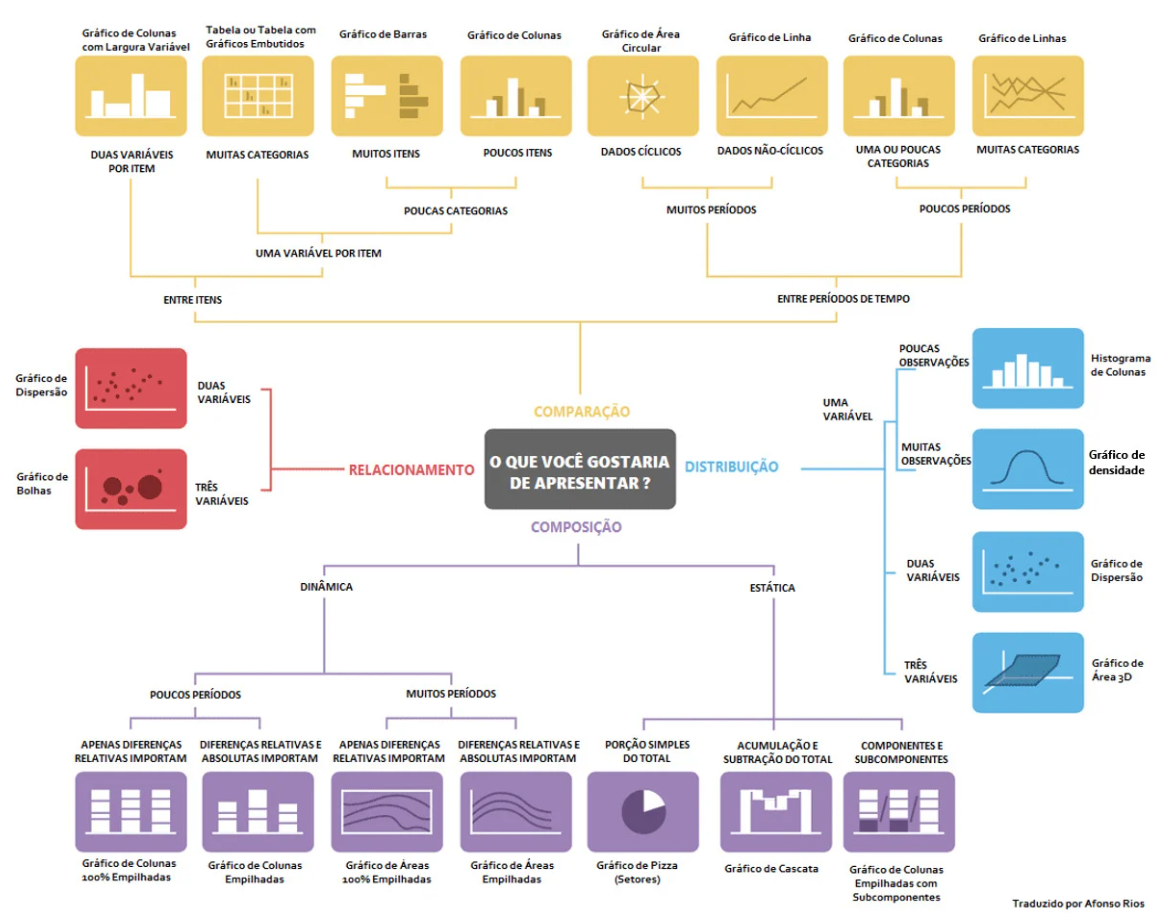

# 1. Importação das Bibliotecas

In [ ]:
import numpy as np # Importa a biblioteca Numpy, que é fundamental para cálculos numéricos e manipulação de arrays.

import pandas as pd # Importa a biblioteca Pandas, usada para manipulação e análise de dados.
pd.set_option('display.float_format', lambda x: '%.5f' % x) # Configura o Pandas para formatar números flutuantes para 5 casas decimais, evitando a notação científica.

import os # Importa a biblioteca de funções do sistema operacional, utilizada para interagir com o sistema de arquivos.

import matplotlib.pyplot as plt # Importa a biblioteca Matplotlib para a criação de gráficos estáticos, animados e interativos.

import gc # Importa o módulo de coleta de lixo, que fornece a possibilidade de liberar memória desalocando objetos que não estão mais em uso.

import chardet # Importa a biblioteca Chardet, utilizada para detectar a codificação de caracteres de arquivos, o que é útil para ler corretamente arquivos CSV.


## 2. Aquisição e Preparação dos Dados

### 2.1 Carregamento dos Arquivos CSV

O dataset é distribuído em arquivos semestrais nomeados no padrão `ca-AAAA-SS.csv`. Utilizamos `os.walk` para varrer recursivamente o diretório `dataset/` e consolidar todos os arquivos em uma única estrutura.

In [ ]:
# Lista para armazenar os nomes dos arquivos .csv
nomes_csv = []

# Lista para armazenar os caminhos completos dos arquivos .csv
caminhos_completos = []

# Diretório onde os arquivos .csv estão armazenados
diretorio_dataset = 'dataset'

# Percorre o diretório e subdiretórios à procura de arquivos .csv
for diretorio_atual, _, arquivos_encontrados in os.walk(diretorio_dataset):
    for arquivo in arquivos_encontrados:
        # Seleciona apenas arquivos com a extensão .csv
        if arquivo.lower().endswith(".csv"):
            nomes_csv.append(arquivo)
            caminhos_completos.append(os.path.join(diretorio_atual, arquivo))

# Ordena as listas para manter a correspondência entre nome e caminho
nomes_csv.sort()
caminhos_completos.sort()

# Imprime a quantidade de arquivos .csv encontrados
print(f"\nTotal de {len(nomes_csv)} arquivos .csv encontrados:")

# Imprime a lista de arquivos .csv numerada
for indice, nome in enumerate(nomes_csv, start=1):
    print(f"{indice} - {nome}")


### 2.2 Leitura Seletiva de Colunas — Otimização de Memória

Em vez de carregar todas as colunas disponíveis, selecionamos apenas as relevantes para as análises planejadas. Essa prática reduz o consumo de memória RAM, especialmente importante quando o dataset possui dezenas de milhares de linhas distribuídas em múltiplos arquivos.

In [3]:


# Lista para armazenar os dataframes carregados
dataframes = []

# Lista para registrar os nomes dos arquivos processados
nomes_arquivos = []

# Processa cada caminho de arquivo na lista de caminhos para carregar os dados
for caminho in caminhos_completos:
       
    try:
        # Abre o arquivo para leitura e usa chardet para detectar a codificação
        with open(caminho, 'rb') as rawdata:
            result = chardet.detect(rawdata.read(10000)) # Lê os primeiros 10000 bytes
        encoding = result['encoding']
        
        # Lê o arquivo CSV com a codificação correta, delimitador e decimal definidos
        df = pd.read_csv(caminho, encoding=encoding, sep=';', decimal=',',
                         usecols=["Municipio", "Produto", "Data da Coleta", 
                                  "Valor de Compra", "Valor de Venda", "Estado - Sigla",
                                  "Regiao - Sigla"],
                         parse_dates=["Data da Coleta"], dayfirst=True)
        
        # Reorganiza as colunas se necessário
        df = df[["Municipio", "Produto", "Data da Coleta","Valor de Compra", 
                 "Valor de Venda", "Estado - Sigla","Regiao - Sigla"]]
        
        # Separa o nome do arquivo do caminho e armazena com as colunas do dataframe
        nome_arquivo = caminho.split("/")[-1]
        
        # Adiciona o dataframe à lista de dataframes
        dataframes.append(df)
        
        # Imprime uma confirmação de sucesso na leitura do arquivo
        print(f"{nome_arquivo}... ok")
        
    except FileNotFoundError:
        # Captura o erro se o arquivo não for encontrado e imprime uma mensagem
        print(f'Arquivo {caminho} não encontrado.')       
    except Exception as e:
        # Captura outros erros durante a leitura do arquivo e continua com o próximo arquivo
        print(f"\n\nErro: ao ler o arquivo {caminho}. Seus dados não foram lidos.\n\nErro: {str(e)}\n\nContinuando o Processamento a partir do próximo arquivo...:")
            
print("\nCriação dos Dataframes Concluída.")  


ca-2004-01.csv... ok
ca-2004-02.csv... ok
ca-2005-01.csv... ok
ca-2005-02.csv... ok
ca-2006-01.csv... ok
ca-2006-02.csv... ok
ca-2007-01.csv... ok
ca-2007-02.csv... ok
ca-2008-01.csv... ok
ca-2008-02.csv... ok
ca-2009-01.csv... ok
ca-2009-02.csv... ok
ca-2010-01.csv... ok
ca-2010-02.csv... ok
ca-2011-01.csv... ok
ca-2011-02.csv... ok
ca-2012-01.csv... ok
ca-2012-02.csv... ok
ca-2013-01.csv... ok
ca-2013-02.csv... ok
ca-2014-01.csv... ok
ca-2014-02.csv... ok
ca-2015-01.csv... ok
ca-2015-02.csv... ok
ca-2016-01.csv... ok
ca-2016-02.csv... ok
ca-2017-01.csv... ok
ca-2017-02.csv... ok
ca-2018-01.csv... ok
ca-2018-02.csv... ok
ca-2019-01.csv... ok
ca-2019-02.csv... ok
ca-2020-01.csv... ok
ca-2020-02.csv... ok
ca-2021-01.csv... ok
ca-2021-02.csv... ok

Criação dos Dataframes Concluída.


### 2.3 Consolidação dos DataFrames

Após carregar cada arquivo em um DataFrame individual, realizamos a concatenação vertical (`axis=0`) para obter um único DataFrame com toda a série histórica.

In [4]:
df_precos = pd.concat(dataframes, axis=0, ignore_index=True)


### 2.4 Liberação de Memória com Garbage Collector

Após a concatenação, as estruturas intermediárias (lista de DataFrames, listas de caminhos) não são mais necessárias. Invocamos o coletor de lixo da geração 2 — onde residem objetos de longa duração — para recuperar a memória imediatamente.

Referência: [módulo `gc` — Python Docs](https://docs.python.org/3/library/gc.html)

In [5]:
del dataframes
del nomes_csv
del caminhos_completos

gc.collect(generation=2)
#é especificamente para forçar a coleta de lixo na geração mais velha,
#onde objetos podem ter sobrevivido a várias passagens do coletor de lixo.

0

### 2.5 Diagnóstico de Valores Ausentes

Antes de qualquer visualização, verificamos a proporção de valores nulos por coluna. Colunas com alta taxa de ausência comprometem a confiabilidade dos gráficos.

In [6]:
# Calcular a porcentagem de valores nulos em cada coluna
percent_null = df_precos.isnull().sum() * 100 / len(df_precos)

# Mostrar o resultado
print(percent_null)

Municipio          0.00000
Produto            0.00000
Data da Coleta     0.00000
Valor de Compra   51.13318
Valor de Venda     0.00000
Estado - Sigla     0.00000
Regiao - Sigla     0.00000
dtype: float64


#### 2.5.1 Remoção de Colunas com Alta Proporção de Nulos

Adotamos um limiar de **50 %** de valores ausentes: colunas que ultrapassam esse limite são descartadas, pois imputação de dados em proporção tão elevada introduziria viés significativo nas análises visuais.

In [7]:
# Definir o limiar de percentual de valores nulos para remover a coluna
limiar_nulos = 50  # Por exemplo, 50%

# Calcular a porcentagem de valores nulos
percent_null = df_precos.isnull().sum() * 100 / len(df_precos)

# Remover colunas com mais de 50% de valores nulos
for col in df_precos.columns:
    if percent_null[col] > limiar_nulos:
        df_precos.drop(col, axis=1, inplace=True)

# Preencher os valores nulos restantes, por exemplo, com a média da coluna
# Você pode escolher outro método como mediana (median()) ou moda (mode())
for col in df_precos.columns:
    if df_precos[col].isnull().any():
        df_precos[col].fillna(df_precos[col].mean(), inplace=True)

# Verificar o resultado
print(df_precos.info())

/tmp/ipykernel_106719/3933603530.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_precos[col].fillna(df_precos[col].mean(), inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21306862 entries, 0 to 21306861
Data columns (total 6 columns):
 #   Column          Dtype         
---  ------          -----         
 0   Municipio       object        
 1   Produto         object        
 2   Data da Coleta  datetime64[ns]
 3   Valor de Venda  float64       
 4   Estado - Sigla  object        
 5   Regiao - Sigla  object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 975.4+ MB
None


## 2.6 Inspeção Inicial dos Dados

Antes de gerar qualquer gráfico, inspecionamos as primeiras linhas para verificar tipos, rótulos de colunas e a consistência geral do conjunto de dados — etapa alinhada ao princípio de *data integrity first*.

In [8]:
print(df_precos.head())

   Municipio   Produto Data da Coleta  Valor de Venda Estado - Sigla  \
0  GUARULHOS  GASOLINA     2004-05-11         1.96700             SP   
1  GUARULHOS    ETANOL     2004-05-11         0.89900             SP   
2  GUARULHOS    DIESEL     2004-05-11         1.29900             SP   
3   SOROCABA  GASOLINA     2004-05-10         1.85000             SP   
4   SOROCABA    ETANOL     2004-05-10         0.78000             SP   

  Regiao - Sigla  
0             SE  
1             SE  
2             SE  
3             SE  
4             SE  


## 3. Visualizações de Comparação

### 3.1 Gráfico de Colunas — Evolução Temporal

**Questão analítica:** Como os preços médios anuais da gasolina se comportaram ao longo da série histórica?

**Escolha do gráfico:** Colunas verticais são indicadas quando o eixo X representa categorias ordenadas (anos), pois facilitam a comparação de magnitudes entre períodos adjacentes.

**Contexto:** A partir de 2016, o mercado brasileiro de combustíveis passou a adotar a Política de Preços de Paridade de Importação (PPI) da Petrobras, atrelando os reajustes às cotações internacionais do petróleo e à variação cambial.

/tmp/ipykernel_106719/4037076585.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ano', y='Preço Médio', data=precos_ano, palette='viridis')


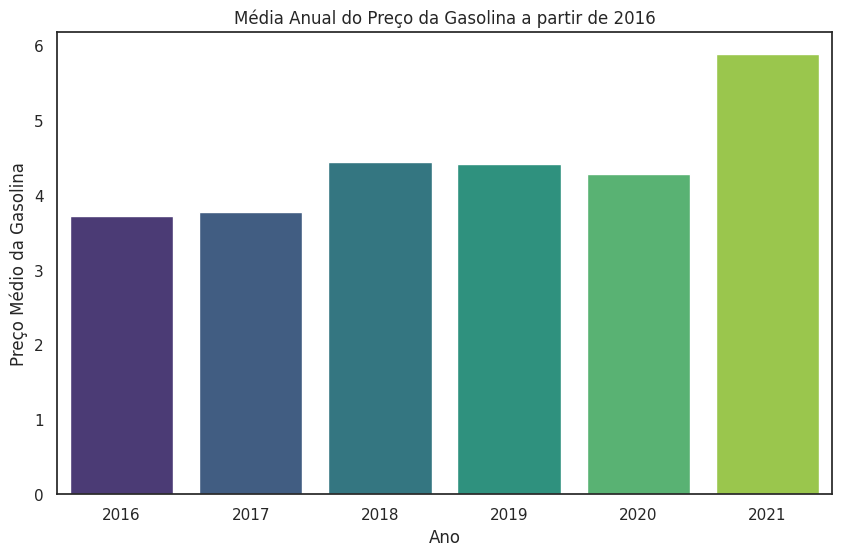

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")

# Carregar o dataset
df = df_precos.copy()

# Filtrar os dados para gasolina e para o período a partir de 2016
gasolina_df = df[(df['Produto'] == 'GASOLINA') & (df['Data da Coleta'].dt.year >= 2016)]

# Agrupar os dados por ano e calcular a média do preço
precos_ano = gasolina_df.groupby(gasolina_df['Data da Coleta'].dt.year)['Valor de Venda'].mean().reset_index()
precos_ano.columns = ['Ano', 'Preço Médio']

# Criar o gráfico de colunas usando seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Ano', y='Preço Médio', data=precos_ano, palette='viridis')
plt.title('Média Anual do Preço da Gasolina a partir de 2016')
plt.xlabel('Ano')
plt.ylabel('Preço Médio da Gasolina')
plt.show()

### 3.2 Personalização Visual com Princípios de Tufte

Tufte (1983) defende que gráficos eficientes maximizam a proporção de *data-ink*: cada traço de tinta deve representar informação real. Os elementos de personalização abaixo servem a esse objetivo:

- **Título e rótulos dos eixos**: eliminam ambiguidade sobre o que está sendo representado  
- **Paleta de cores coerente**: facilita a decodificação sem sobrecarregar a percepção  
- **Tamanho da figura**: garante legibilidade em apresentações e relatórios  
- **Remoção de bordas desnecessárias (`spines`)**: reduz ruído visual sem perda de informação

/tmp/ipykernel_106719/1960590431.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Ano', y='Preço Médio', data=precos_ano, palette='coolwarm')


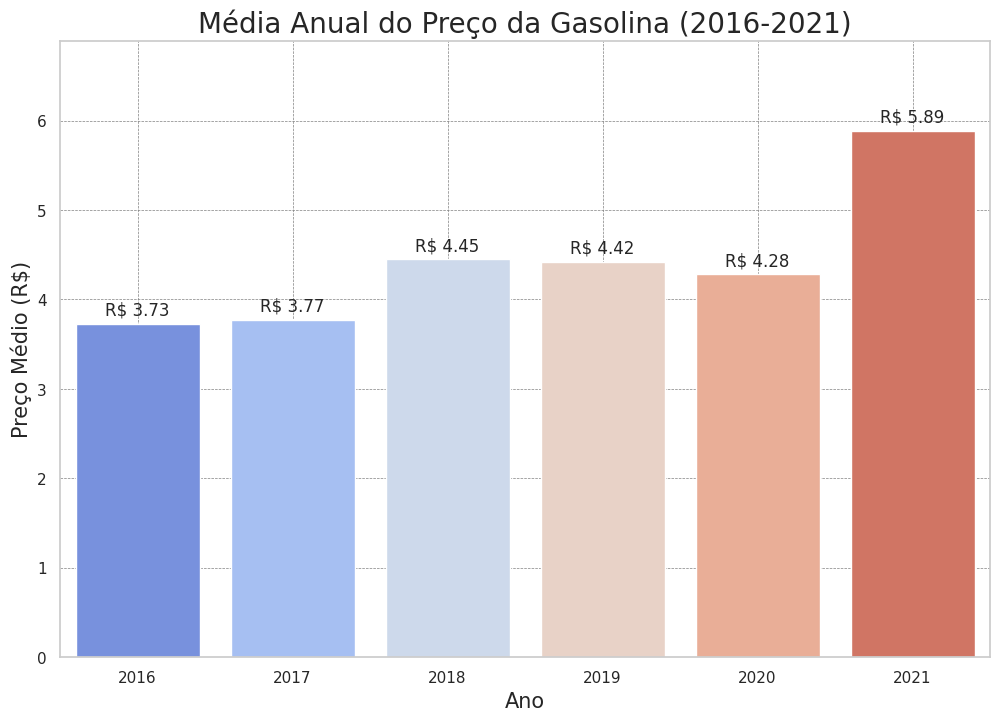

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")

# Carregar o dataset
df = df_precos.copy()

# Filtrar os dados para gasolina e para o período a partir de 2016
gasolina_df = df[(df['Produto'] == 'GASOLINA') & (df['Data da Coleta'].dt.year >= 2016)]

# Agrupar os dados por ano e calcular a média do preço
precos_ano = gasolina_df.groupby(gasolina_df['Data da Coleta'].dt.year)['Valor de Venda'].mean().reset_index()
precos_ano.columns = ['Ano', 'Preço Médio']

# Configurações do gráfico
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
barplot = sns.barplot(x='Ano', y='Preço Médio', data=precos_ano, palette='coolwarm')

# Adicionar o preço médio sobre cada coluna
for p in barplot.patches:
    barplot.annotate("R$ "+ format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 10), 
                     textcoords = 'offset points')

    
# Personalizações
plt.title('Média Anual do Preço da Gasolina (2016-2021)', fontsize=20)
plt.xlabel('Ano', fontsize=15)
plt.ylabel('Preço Médio (R$)', fontsize=15)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.ylim(0, precos_ano['Preço Médio'].max() + 1)  # Adiciona um espaço no topo do gráfico

# Exibir o gráfico
plt.show()

### 3.2.1 Anotações Contextuais no Gráfico

Uma técnica poderosa de comunicação visual é inserir **anotações** diretamente sobre o gráfico para conectar os dados a eventos do mundo real, eliminando a necessidade de o leitor consultar fontes externas para interpretar picos ou vales.

**Evento anotado:** O aumento expressivo nos preços da gasolina verificado em 2021 resultou da combinação de fatores: recuperação da demanda global pós-pandemia, depreciação do real frente ao dólar e reajustes alinhados à paridade internacional via PPI/Petrobras.

/tmp/ipykernel_106719/450839488.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Ano', y='Preço Médio', data=precos_ano, palette='coolwarm')
/home/nees/Documents/VSCodigo/DisciplinaMineracaoDados/venv/lib/python3.11/site-packages/matplotlib/text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))


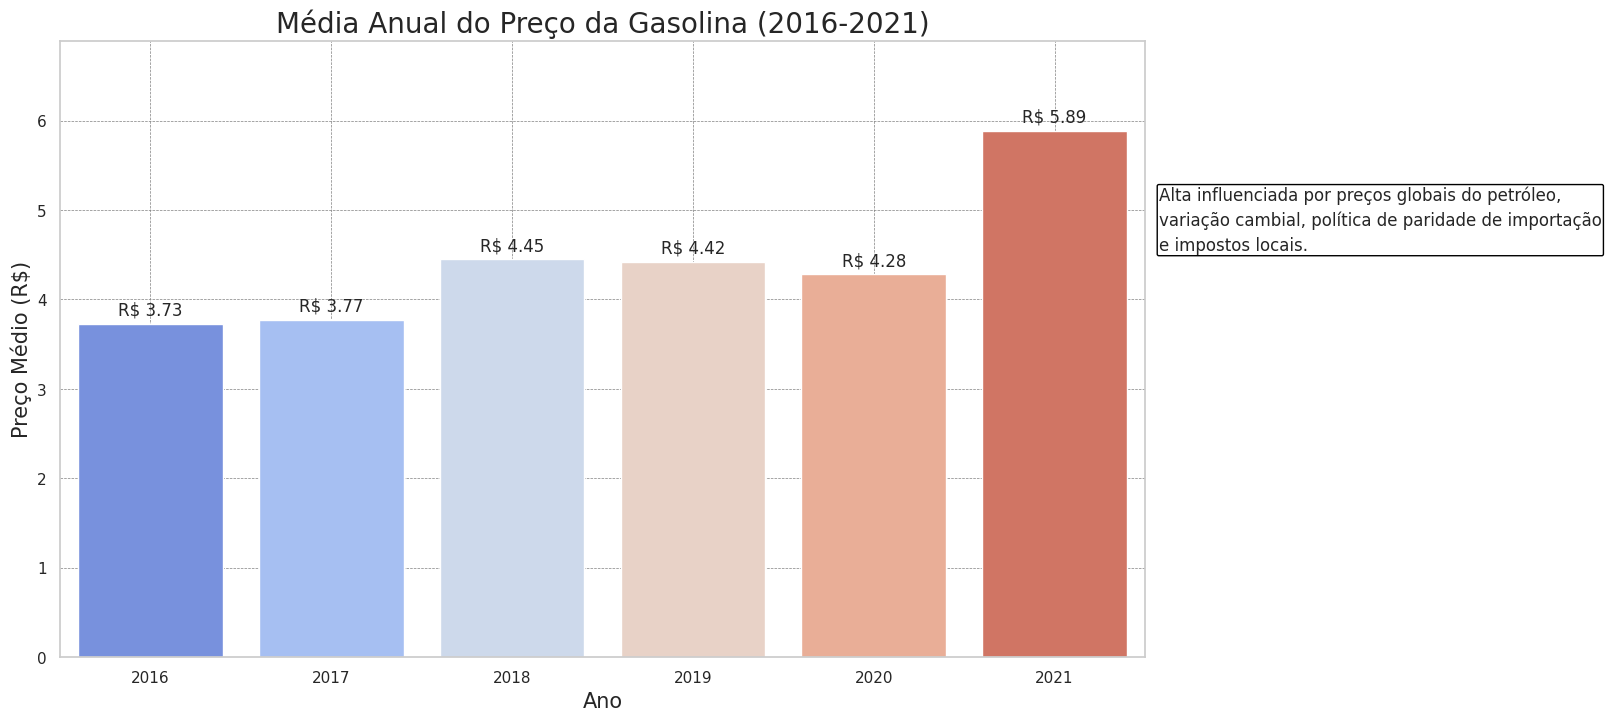

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")

# Carregar o dataset
df = df_precos.copy()

# Filtrar os dados para gasolina e para o período a partir de 2016
gasolina_df = df[(df['Produto'] == 'GASOLINA') & (df['Data da Coleta'].dt.year >= 2016)]

# Agrupar os dados por ano e calcular a média do preço
precos_ano = gasolina_df.groupby(gasolina_df['Data da Coleta'].dt.year)['Valor de Venda'].mean().reset_index()
precos_ano.columns = ['Ano', 'Preço Médio']

# Configurações do gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
barplot = sns.barplot(x='Ano', y='Preço Médio', data=precos_ano, palette='coolwarm')

# Adicionar o preço médio sobre cada coluna
for p in barplot.patches:
    barplot.annotate("R$ "+ format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 10), 
                     textcoords = 'offset points')
    
# Personalizações
plt.title('Média Anual do Preço da Gasolina (2016-2021)', fontsize=20)
plt.xlabel('Ano', fontsize=15)
plt.ylabel('Preço Médio (R$)', fontsize=15)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.ylim(0, precos_ano['Preço Médio'].max() + 1)  # Adiciona um espaço no topo do gráfico


# Texto resumido dos fatores para a alta do preço em 2021
texto_informativo = ("Alta influenciada por preços globais do petróleo,\n"
                     "variação cambial, política de paridade de importação\n"
                     "e impostos locais.")

# Coordenadas para a localização da anotação na coluna de 2021
preco_medio_2021 = precos_ano[precos_ano['Ano']==2021]['Preço Médio']
y_coordenada = preco_medio_2021 - 1

# Adicionar anotação
plt.annotate(texto_informativo, 
             xy=(5.5, y_coordenada),# Posição base da anotação, assumindo que 2021 é a 6ª barra (índice 5)
             textcoords="offset points", xytext=(10,0),
             ha='left', va='center',  fontsize=12, linespacing=1.45,
             bbox=dict(boxstyle="round,pad=0.1", edgecolor='black', facecolor='white'))


plt.show()

### Destaque de Ponto Focal

O conceito de **ponto focal** na visualização de dados refere-se ao elemento visual que captura primeiro a atenção do leitor. Estratégias para construí-lo:

- **Cor contrastante** no ponto de maior interesse (pico, vale ou ruptura de tendência)  
- **Seta ou linha de referência** apontando para o evento  
- **Texto explicativo** curto e posicionado próximo ao dado sem poluir o espaço do gráfico  

> *"Above all else, show the data."* — Edward Tufte, *The Visual Display of Quantitative Information* (1983)

/tmp/ipykernel_106719/2491847710.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Ano', y='Preço Médio', data=precos_ano, palette=palette)


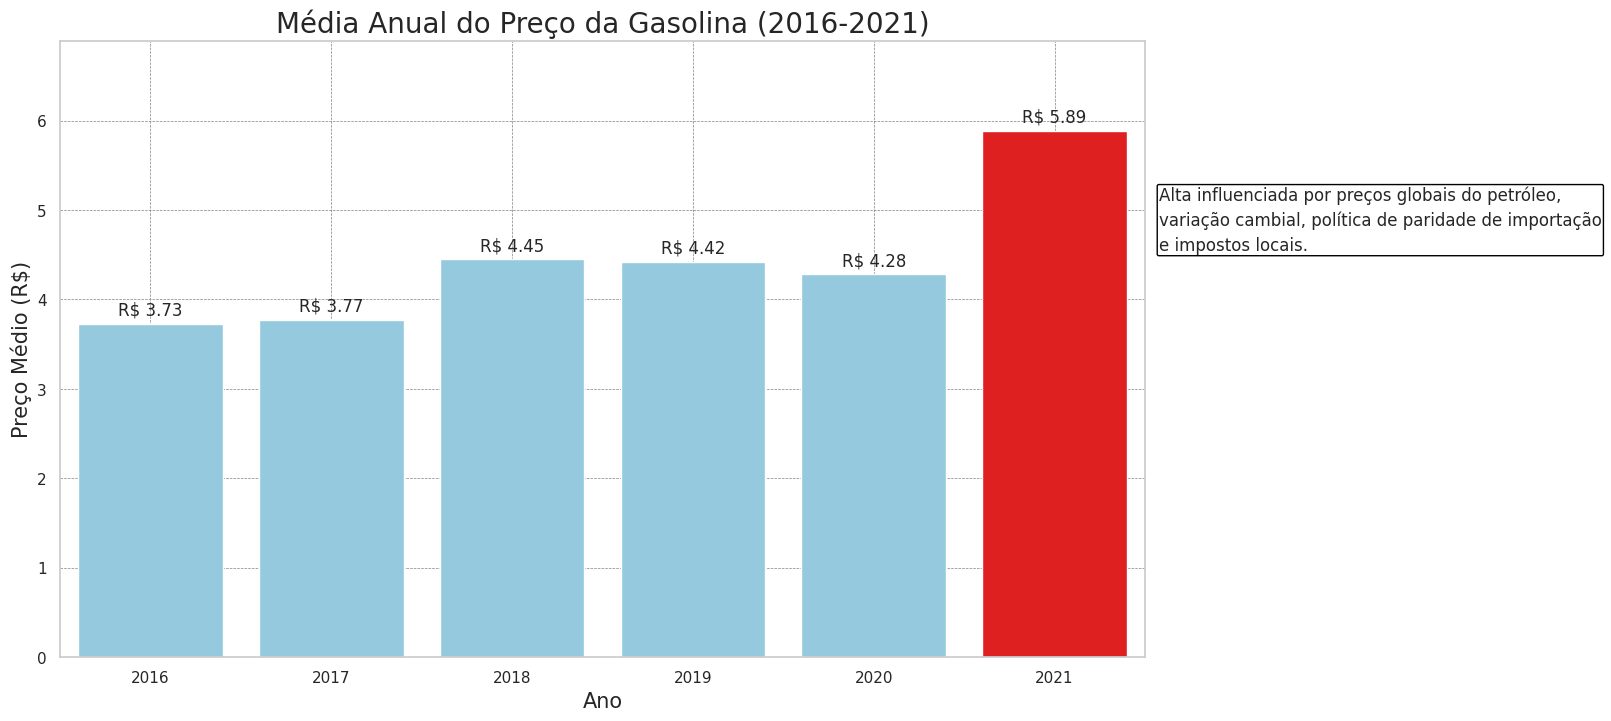

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")

# Carregar o dataset
df = df_precos.copy()

# Filtrar os dados para gasolina e para o período a partir de 2016
gasolina_df = df[(df['Produto'] == 'GASOLINA') & (df['Data da Coleta'].dt.year >= 2016)]

# Agrupar os dados por ano e calcular a média do preço
precos_ano = gasolina_df.groupby(gasolina_df['Data da Coleta'].dt.year)['Valor de Venda'].mean().reset_index()
precos_ano.columns = ['Ano', 'Preço Médio']

# Configurações do gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Criação de uma paleta de cores onde o preço médio acima de R$ 5 é destacado
palette = ["red" if x > 5 else "skyblue" for x in precos_ano['Preço Médio']]
barplot = sns.barplot(x='Ano', y='Preço Médio', data=precos_ano, palette=palette)

# Adicionar o preço médio sobre cada coluna
for p in barplot.patches:
    barplot.annotate("R$ "+ format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 10), 
                     textcoords = 'offset points')
    
# Personalizações
plt.title('Média Anual do Preço da Gasolina (2016-2021)', fontsize=20)
plt.xlabel('Ano', fontsize=15)
plt.ylabel('Preço Médio (R$)', fontsize=15)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.ylim(0, precos_ano['Preço Médio'].max() + 1)  # Adiciona um espaço no topo do gráfico


# Texto resumido dos fatores para a alta do preço em 2021
texto_informativo = ("Alta influenciada por preços globais do petróleo,\n"
                     "variação cambial, política de paridade de importação\n"
                     "e impostos locais.")

# Coordenadas para a localização da anotação na coluna de 2021
preco_medio_2021 = precos_ano[precos_ano['Ano']==2021]['Preço Médio'].iloc[0]
y_coordenada = preco_medio_2021 - 1

# Adicionar anotação
plt.annotate(texto_informativo, 
             xy=(5.5, y_coordenada),# Posição base da anotação, assumindo que 2021 é a 6ª barra (índice 5)
             textcoords="offset points", xytext=(10,0),
             ha='left', va='center',  fontsize=12, linespacing=1.45,
             bbox=dict(boxstyle="round,pad=0.1", edgecolor='black', facecolor='white'))


plt.show()

### 3.3 Gráfico de Barras Horizontais com Comparação entre Categorias

**Questão analítica:** Qual a dispersão do preço médio de venda do etanol entre os municípios de um estado em um período específico?

**Escolha do gráfico:** Barras horizontais são preferíveis a colunas verticais quando os rótulos das categorias são longos (nomes de municípios), pois evitam rotação de texto e melhoram a legibilidade.

/tmp/ipykernel_106719/2242645856.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


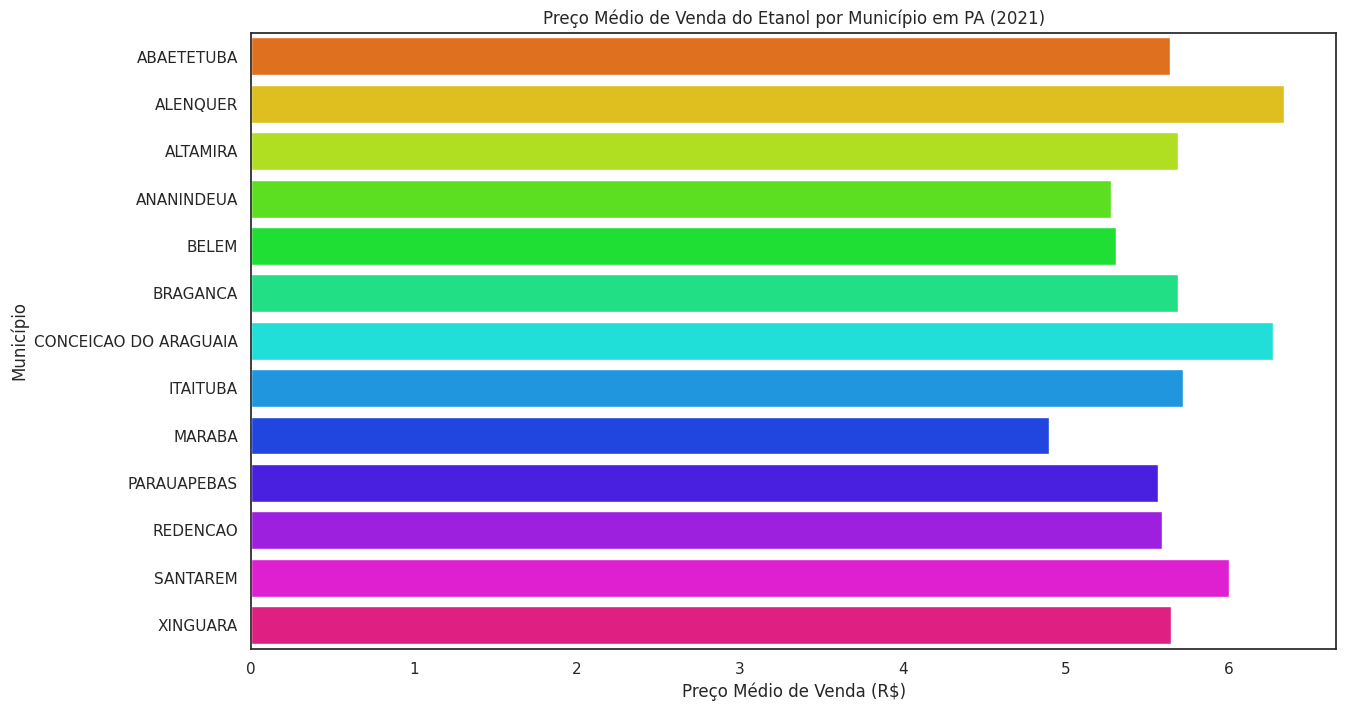

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")

# Carregar o dataset
df = df_precos.copy()


# Filtrar os dados para etanol e para o ano de 2021 no estado específico (ex: "PA")
etanol_df_2021 = df[(df['Produto'] == 'ETANOL') & 
                    (df['Data da Coleta'].dt.year == 2021) & 
                    (df['Estado - Sigla'] == 'PA')]

# Agrupar os dados por município e calcular a média do preço de venda
#preco_medio_por_municipio = etanol_df_2021.groupby('Municipio')['Valor de Venda'].mean().sort_values(ascending=False).reset_index()
preco_medio_por_municipio = etanol_df_2021.groupby('Municipio')['Valor de Venda'].mean().reset_index()

preco_medio_por_municipio.columns = ['Municipio', 'Preco Medio']

# Cria o gráfico de barras com os municípios no eixo y e o preço médio de venda no eixo x
plt.figure(figsize=(14, 8))
barplot = sns.barplot(
    y='Municipio',
    x='Preco Medio',
    data=preco_medio_por_municipio,
    palette='hsv'
)

plt.title('Preço Médio de Venda do Etanol por Município em PA (2021)')
plt.xlabel('Preço Médio de Venda (R$)')
plt.ylabel('Município')
plt.show()


### Ordenação como Estratégia Visual

A ordenação das barras do maior para o menor valor transforma o gráfico em um **ranking imediato**, dispensando o leitor de varrer visualmente toda a lista para encontrar extremos. Segundo o princípio de *preattentive processing*, a posição é o atributo visual mais rápido de decodificar, logo a importância de ordenar antes de exibir.

/tmp/ipykernel_106719/625478868.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


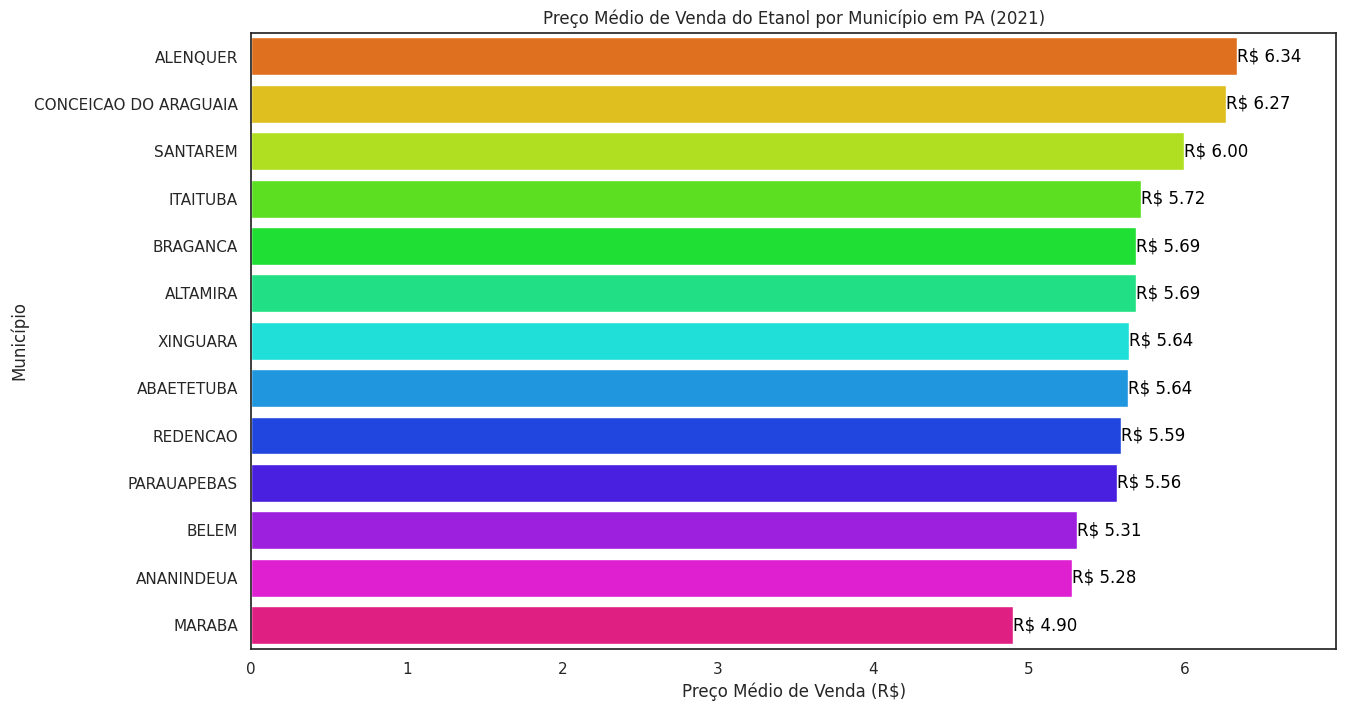

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")

# Carregar o dataset
df = df_precos.copy()


# Filtrar os dados para etanol e para o ano de 2021 no estado específico (ex: "PA")
etanol_df_2021 = df[(df['Produto'] == 'ETANOL') & 
                    (df['Data da Coleta'].dt.year == 2021) & 
                    (df['Estado - Sigla'] == 'PA')]

# Agrupar os dados por município e calcular a média do preço de venda
preco_medio_por_municipio = etanol_df_2021.groupby('Municipio')['Valor de Venda'].mean().sort_values(ascending=False).reset_index()

preco_medio_por_municipio.columns = ['Municipio', 'Preco Medio']

# Cria o gráfico de barras com os municípios no eixo y e o preço médio de venda no eixo x
plt.figure(figsize=(14, 8))
barplot = sns.barplot(
    y='Municipio',
    x='Preco Medio',
    data=preco_medio_por_municipio,
    palette='hsv'   
)

#Personalização
# Adicionar o valor do preço médio do etanol na extremidade direita de cada barra
for index, row in preco_medio_por_municipio.iterrows():
    barplot.text(row['Preco Medio'], index, f'R$ {row["Preco Medio"]:.2f}', color='black', ha="left", va="center")


plt.title('Preço Médio de Venda do Etanol por Município em PA (2021)')
plt.xlabel('Preço Médio de Venda (R$)')
plt.ylabel('Município')

# Ajuste a extensão do eixo x se necessário para acomodar os textos
plt.xlim(0, preco_medio_por_municipio['Preco Medio'].max() * 1.1)
plt.show()


### Gradiente de Cores para Reforçar o Ranking

A aplicação de um gradiente de cores mapeia a **magnitude do valor** a um atributo visual adicional (cor), criando redundância perceptual: o leitor recebe a mesma informação por dois canais (posição + cor). Essa redundância reforça o ponto focal sem adicionar ruído.

No mapeamento perceptual de Bertin (1967), a **cor** é mais eficaz para comunicar diferenças de **ordem** (escala), enquanto **forma** e **textura** servem melhor à **identidade** de categorias.

/tmp/ipykernel_106719/108288073.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/tmp/ipykernel_106719/108288073.py:36: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  barplot = sns.barplot(


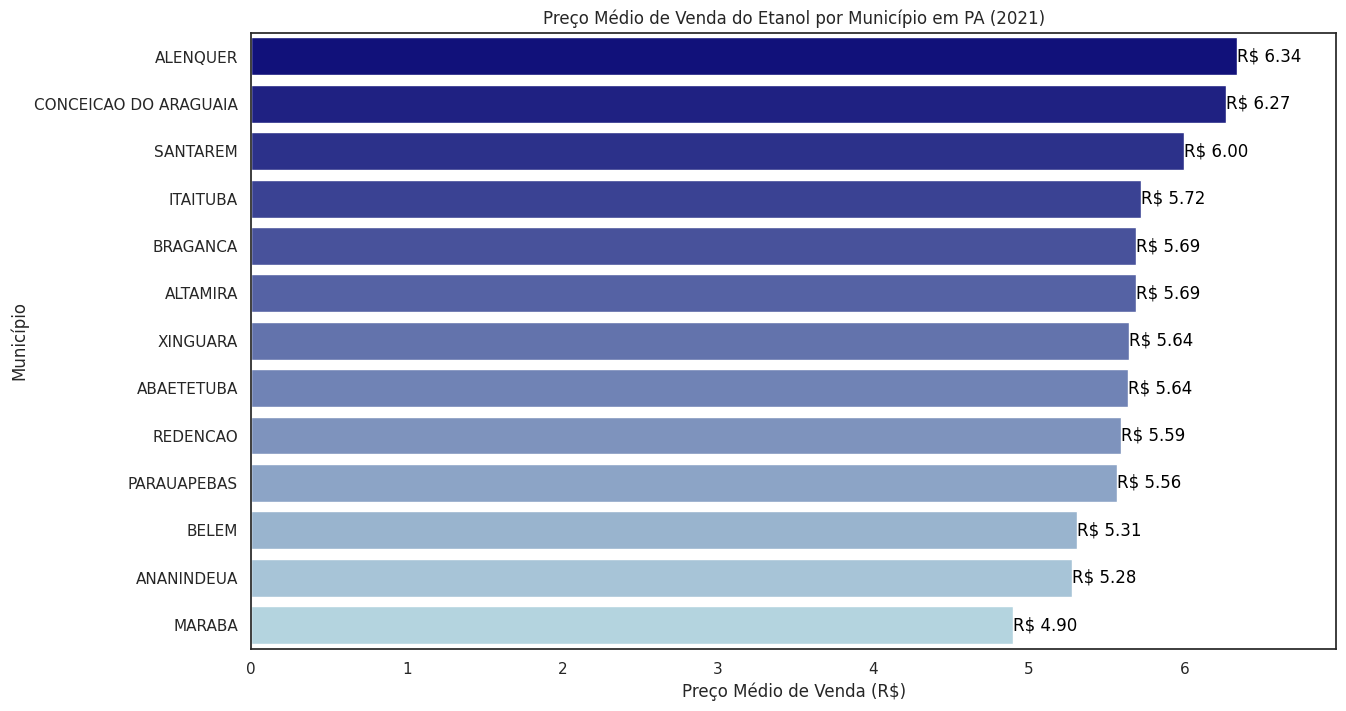

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sns.set_theme(style="white")


# Carregar o dataset
df = df_precos.copy()

# Filtrar os dados para etanol e para o ano de 2021 no estado específico (ex: "PA")
etanol_df_2021 = df[(df['Produto'] == 'ETANOL') & 
                    (df['Data da Coleta'].dt.year == 2021) & 
                    (df['Estado - Sigla'] == 'PA')]

# Agrupar os dados por município e calcular a média do preço de venda
preco_medio_por_municipio = etanol_df_2021.groupby('Municipio')['Valor de Venda'].mean().sort_values(ascending=False).reset_index()
preco_medio_por_municipio.columns = ['Municipio', 'Preco Medio']


# Definir as cores de início e fim do gradiente
cor_clara = '#add8e6'  # azul claro
cor_escura = '#00008b'    # azul escuro

# Criar o objeto colormap
custom_colormap = LinearSegmentedColormap.from_list('custom_gradient', 
                                                    [cor_escura,cor_clara])

# Agora, vamos obter as cores de nosso colormap
num_colors = preco_medio_por_municipio.shape[0]
colors = custom_colormap(np.linspace(0, 1, num_colors))


# Cria o gráfico de barras com os municípios no eixo y e o preço médio de venda no eixo x
plt.figure(figsize=(14, 8))
barplot = sns.barplot(
    y='Municipio',
    x='Preco Medio',
    data=preco_medio_por_municipio,
    palette=colors  # Use a lista de cores extraída do colormap  
)

# Adicionar o valor do preço médio do etanol na extremidade direita de cada barra
for index, row in preco_medio_por_municipio.iterrows():
    barplot.text(row['Preco Medio'], index, f'R$ {row["Preco Medio"]:.2f}', color='black', ha="left", va="center")


plt.title('Preço Médio de Venda do Etanol por Município em PA (2021)')
plt.xlabel('Preço Médio de Venda (R$)')
plt.ylabel('Município')

# Ajuste a extensão do eixo x se necessário para acomodar os textos
plt.xlim(0, preco_medio_por_municipio['Preco Medio'].max() * 1.1)
plt.show()

### Armadilha: Excesso de Categorias no Gráfico

Quando o número de itens é muito elevado (ex.: todos os municípios de um estado), o gráfico se torna ilegível: rótulos sobrepostos, barras excessivamente finas. Esse é um exemplo clássico do que Tufte chama de *chartjunk por excesso de dados não filtrados*.

**Exemplo a seguir:** visualização problemática com todos os municípios que sirva como contraste para as boas práticas que vêm depois.

/tmp/ipykernel_106719/2462998653.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/tmp/ipykernel_106719/2462998653.py:38: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  barplot = sns.barplot(


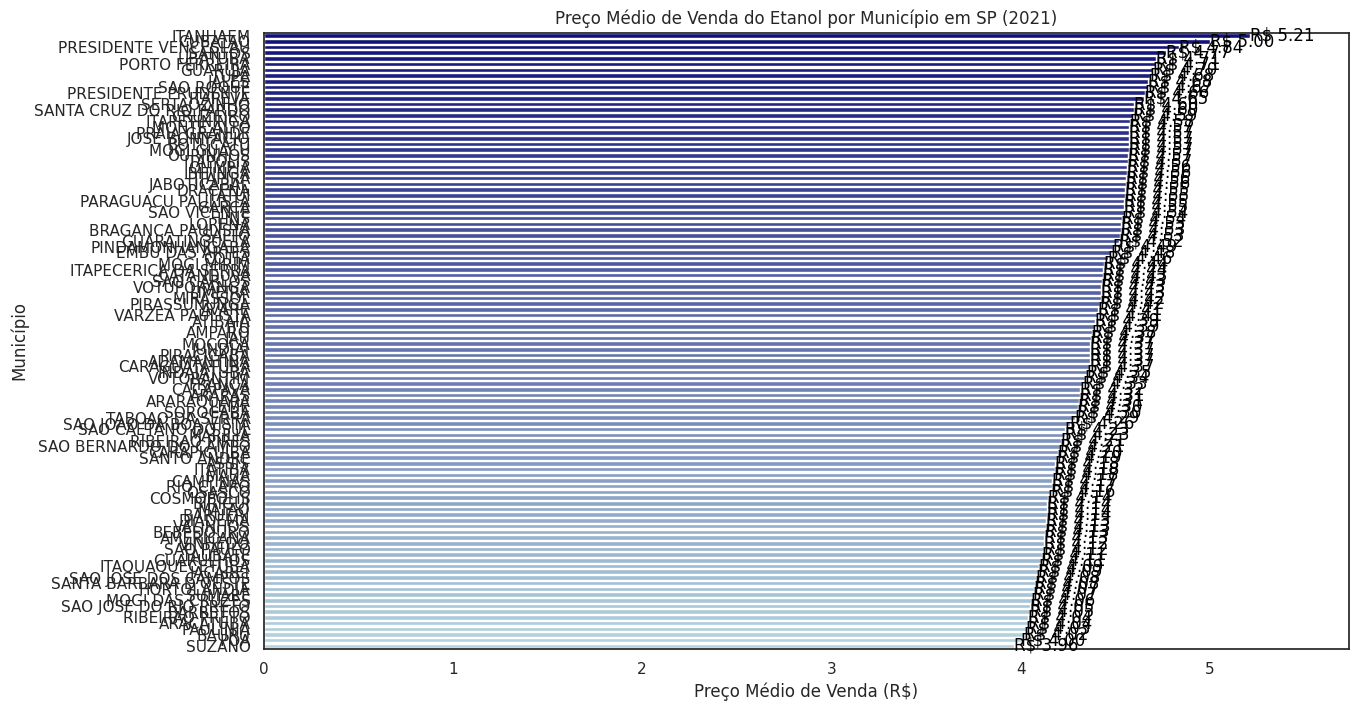

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sns.set_theme(style="white")

# Carregar o dataset
df = df_precos.copy()


# Filtrar os dados para etanol e para o ano de 2021 no estado específico (ex: "PA")
etanol_df_2021 = df[(df['Produto'] == 'ETANOL') & 
                    (df['Data da Coleta'].dt.year == 2021) & 
                    (df['Estado - Sigla'] == 'SP')]

# Agrupar os dados por município e calcular a média do preço de venda
preco_medio_por_municipio = etanol_df_2021.groupby('Municipio')['Valor de Venda'].mean().sort_values(ascending=False).reset_index()
preco_medio_por_municipio.columns = ['Municipio', 'Preco Medio']

#df_1 = preco_medio_por_municipio[:10]
#df_2 = preco_medio_por_municipio[-10:]
#preco_medio_por_municipio = pd.concat([df_1,df_2]).reset_index(drop=True)

# Definir as cores de início e fim do gradiente
cor_clara = '#add8e6'  # azul claro
cor_escura = '#00008b'    # azul escuro

# Criar o objeto colormap
custom_colormap = LinearSegmentedColormap.from_list('custom_gradient', [cor_escura,cor_clara])

# Agora, vamos obter as cores de nosso colormap
num_colors = preco_medio_por_municipio.shape[0]
colors = custom_colormap(np.linspace(0, 1, num_colors))


# Cria o gráfico de barras com os municípios no eixo y e o preço médio de venda no eixo x
plt.figure(figsize=(14, 8))
barplot = sns.barplot(
    y='Municipio',
    x='Preco Medio',
    data=preco_medio_por_municipio,
    palette=colors  # Use a lista de cores extraída do colormap  
)

# Adicionar o valor do preço médio do etanol na extremidade direita de cada barra
for index, row in preco_medio_por_municipio.iterrows():
    barplot.text(row['Preco Medio'], index, f'R$ {row["Preco Medio"]:.2f}', color='black', ha="left", va="center")


plt.title('Preço Médio de Venda do Etanol por Município em SP (2021)')
plt.xlabel('Preço Médio de Venda (R$)')
plt.ylabel('Município')

# Ajuste a extensão do eixo x se necessário para acomodar os textos
plt.xlim(0, preco_medio_por_municipio['Preco Medio'].max() * 1.1)
plt.show()

### Solução: Redução Intencional do Escopo Visual

A escolha de exibir **Top-N categorias** é uma decisão analítica consciente, não uma limitação técnica. Ela direciona o leitor para os elementos mais relevantes e elimina o ruído dos casos intermediários.

Estratégias aplicáveis:
- **Top N / Bottom N**: exibir apenas os municípios com preços mais altos e mais baixos  
- **Filtragem por limiar**: incluir somente municípios com diferença acima de X% da mediana  
- **Agregação geográfica**: subir para nível regional quando o município é muito granular

## 3.4 Gráficos de Colunas Empilhadas com Composição e Comparação Simultâneas

### Quando Usar Colunas Empilhadas?

Colunas empilhadas são adequadas quando o interesse analítico está em **duas dimensões simultâneas**:

1. **Total da categoria** (altura da coluna): permite comparar o volume entre anos  
2. **Composição interna** (cor de cada segmento): revela a participação de cada subcategoria  

**Limitação:** a comparação entre segmentos intermediários é difícil, pois suas bases variam. Se a prioridade for comparar subcategorias, prefira colunas agrupadas (*grouped bar chart*).

**Questão analítica:** Como evoluiu, ano a ano, a composição regional dos registros de preços da gasolina?

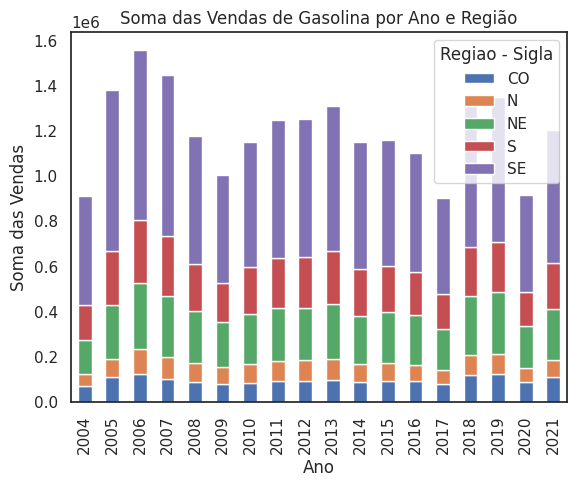

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o dataset
df = df_precos.copy()
df['Ano'] = df['Data da Coleta'].dt.year
df = df[df['Produto'] == 'GASOLINA']
# Criando o crosstab
vendas_crosstab = pd.crosstab(index= df['Ano'], columns = df['Regiao - Sigla'], 
                              values=df['Valor de Venda'], aggfunc='sum')


# Plotando o gráfico de colunas empilhadas
vendas_crosstab.plot(kind='bar', stacked=True)
plt.title('Soma das Vendas de Gasolina por Ano e Região')
plt.xlabel('Ano')
plt.ylabel('Soma das Vendas')
plt.show()


### 3.4.1 Refinamento Visual das Colunas Empilhadas

#### Posicionamento da Legenda

A legenda padrão do Matplotlib frequentemente sobrepõe os dados ou desperdiça espaço interno do gráfico. O deslocamento para fora da área de plotagem (`bbox_to_anchor`) resolve esse problema sem sacrificar a proporção *data-ink*:

```python
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
```

#### Remoção de Bordas Desnecessárias

As bordas laterais e superiores do gráfico (`spines`) não carregam informação adicional. Removê-las reduz o ruído visual e dá mais destaque aos dados sendo aplicação direta do princípio de economia visual de Tufte:

```python
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
```

#### Correspondência entre Cores da Legenda e das Barras

A ordem padrão da legenda no Matplotlib pode não coincidir com a ordem visual das barras empilhadas, forçando o leitor a cruzar referências. Inverter a ordem (`reverse=True`) alinha a legenda à leitura natural de cima para baixo.

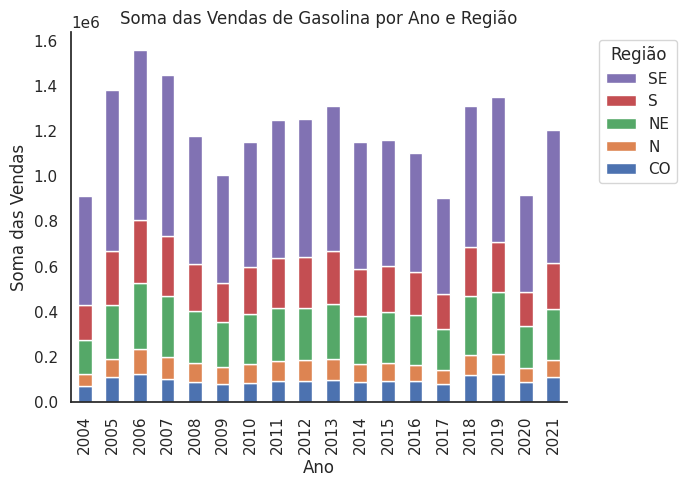

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o dataset
df = df_precos.copy()
df = df[df['Produto'] == 'GASOLINA']
df['Ano'] = df['Data da Coleta'].dt.year
# Criando o crosstab
vendas_crosstab = pd.crosstab(index= df['Ano'], columns = df['Regiao - Sigla'], values=df['Valor de Venda'], aggfunc='sum')


# Aumentando o tamanho do gráfico

# Plotando o gráfico de colunas empilhadas
vendas_crosstab.plot(kind='bar', stacked=True)

# Ajustando a legenda
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left', reverse=True)

# Removendo as bordas laterais
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Adicionando título e rótulos dos eixos
plt.title('Soma das Vendas de Gasolina por Ano e Região')
plt.xlabel('Ano')
plt.ylabel('Soma das Vendas')

# Mostrando o gráfico
plt.show()

### Rótulos Diretamente nas Barras

Adicionar os valores numéricos diretamente sobre cada segmento elimina a necessidade de o leitor estimar alturas ou consultar o eixo Y reduzindo a carga cognitiva. Usamos `ax.text()` dentro de um loop sobre os `patches` do gráfico.

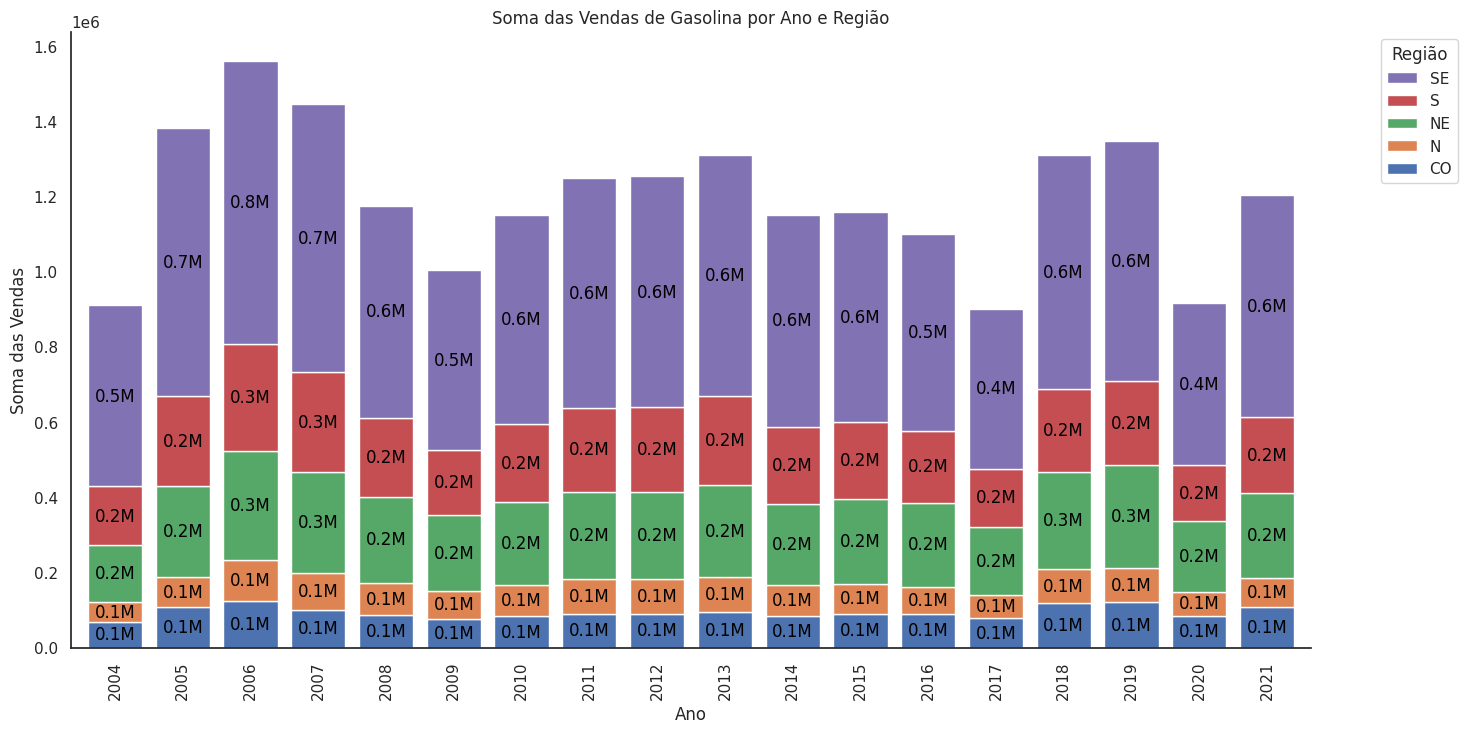

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o dataset
df = df_precos.copy()
df = df[df['Produto'] == 'GASOLINA']
df['Ano'] = df['Data da Coleta'].dt.year

# Criando o crosstab
vendas_crosstab = pd.crosstab(index= df['Ano'], columns = df['Regiao - Sigla'], 
                              values=df['Valor de Venda'], aggfunc='sum')


# Plotando o gráfico de colunas empilhadas
ax = vendas_crosstab.plot(kind='bar', stacked=True,width=0.8,figsize=(16, 8))

# Ajustando a legenda
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left', reverse=True)

# Adicionando labels aos valores em cada barra
for barra in ax.containers:
    ax.bar_label(barra, label_type='center', fmt=lambda x: f'{x*1e-6:.1f}M',
                 fontsize=12, color='black')

    
# Removendo as bordas laterais
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Adicionando título e rótulos dos eixos
plt.title('Soma das Vendas de Gasolina por Ano e Região')
plt.xlabel('Ano')
plt.ylabel('Soma das Vendas')

# Mostrando o gráfico
plt.show()

#### Notas sobre os parâmetros do código

- **`width=0.8`**: aumenta a largura das barras, reduzindo o espaço entre elas e tornando a comparação mais imediata  
- **`fmt=lambda x: f'{x*1e-6:.1f}M'`**: formata os rótulos em milhões, evitando números com muitos zeros que dificultam a leitura  
- **`va='center'`**: centraliza verticalmente o texto dentro do segmento, independentemente da altura

### 3.4.2 Valores Absolutos vs. Valores Relativos

A escolha entre representar magnitudes absolutas ou proporções relativas depende da **pergunta analítica**:

| Representação | Responde a | Risco |
|---|---|---|
| **Absoluta** | "Quanto?" | Oculta diferenças de escala entre categorias |
| **Relativa (%)** | "Qual a participação?" | Oculta diferenças de volume total |

**Boas práticas:** exibir os dois lado a lado (gráfico duplo) quando ambas as perspectivas importam para a interpretação.

In [21]:
# Carregar o dataset
df = df_precos.copy()
df['Ano'] = df['Data da Coleta'].dt.year
df = df[df['Ano'].isin([2020,2021])]

# Criando o crosstab
vendas_crosstab = pd.crosstab(index= df['Ano'], columns = df['Produto'], 
                              values=df['Valor de Venda'], aggfunc='sum')


vendas_crosstab

Produto,DIESEL,DIESEL S10,ETANOL,GASOLINA,GASOLINA ADITIVADA,GNV
Ano,,,,,,
2020,371688.73400,624253.56000,605462.55200,916130.99000,71491.57400,39533.78200
2021,412642.16000,779858.29500,854203.17700,1203485.68200,917941.89100,61401.59200


/tmp/ipykernel_106719/3930479591.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(['{:.0%}'.format(y) for y in ax[1].get_yticks()])


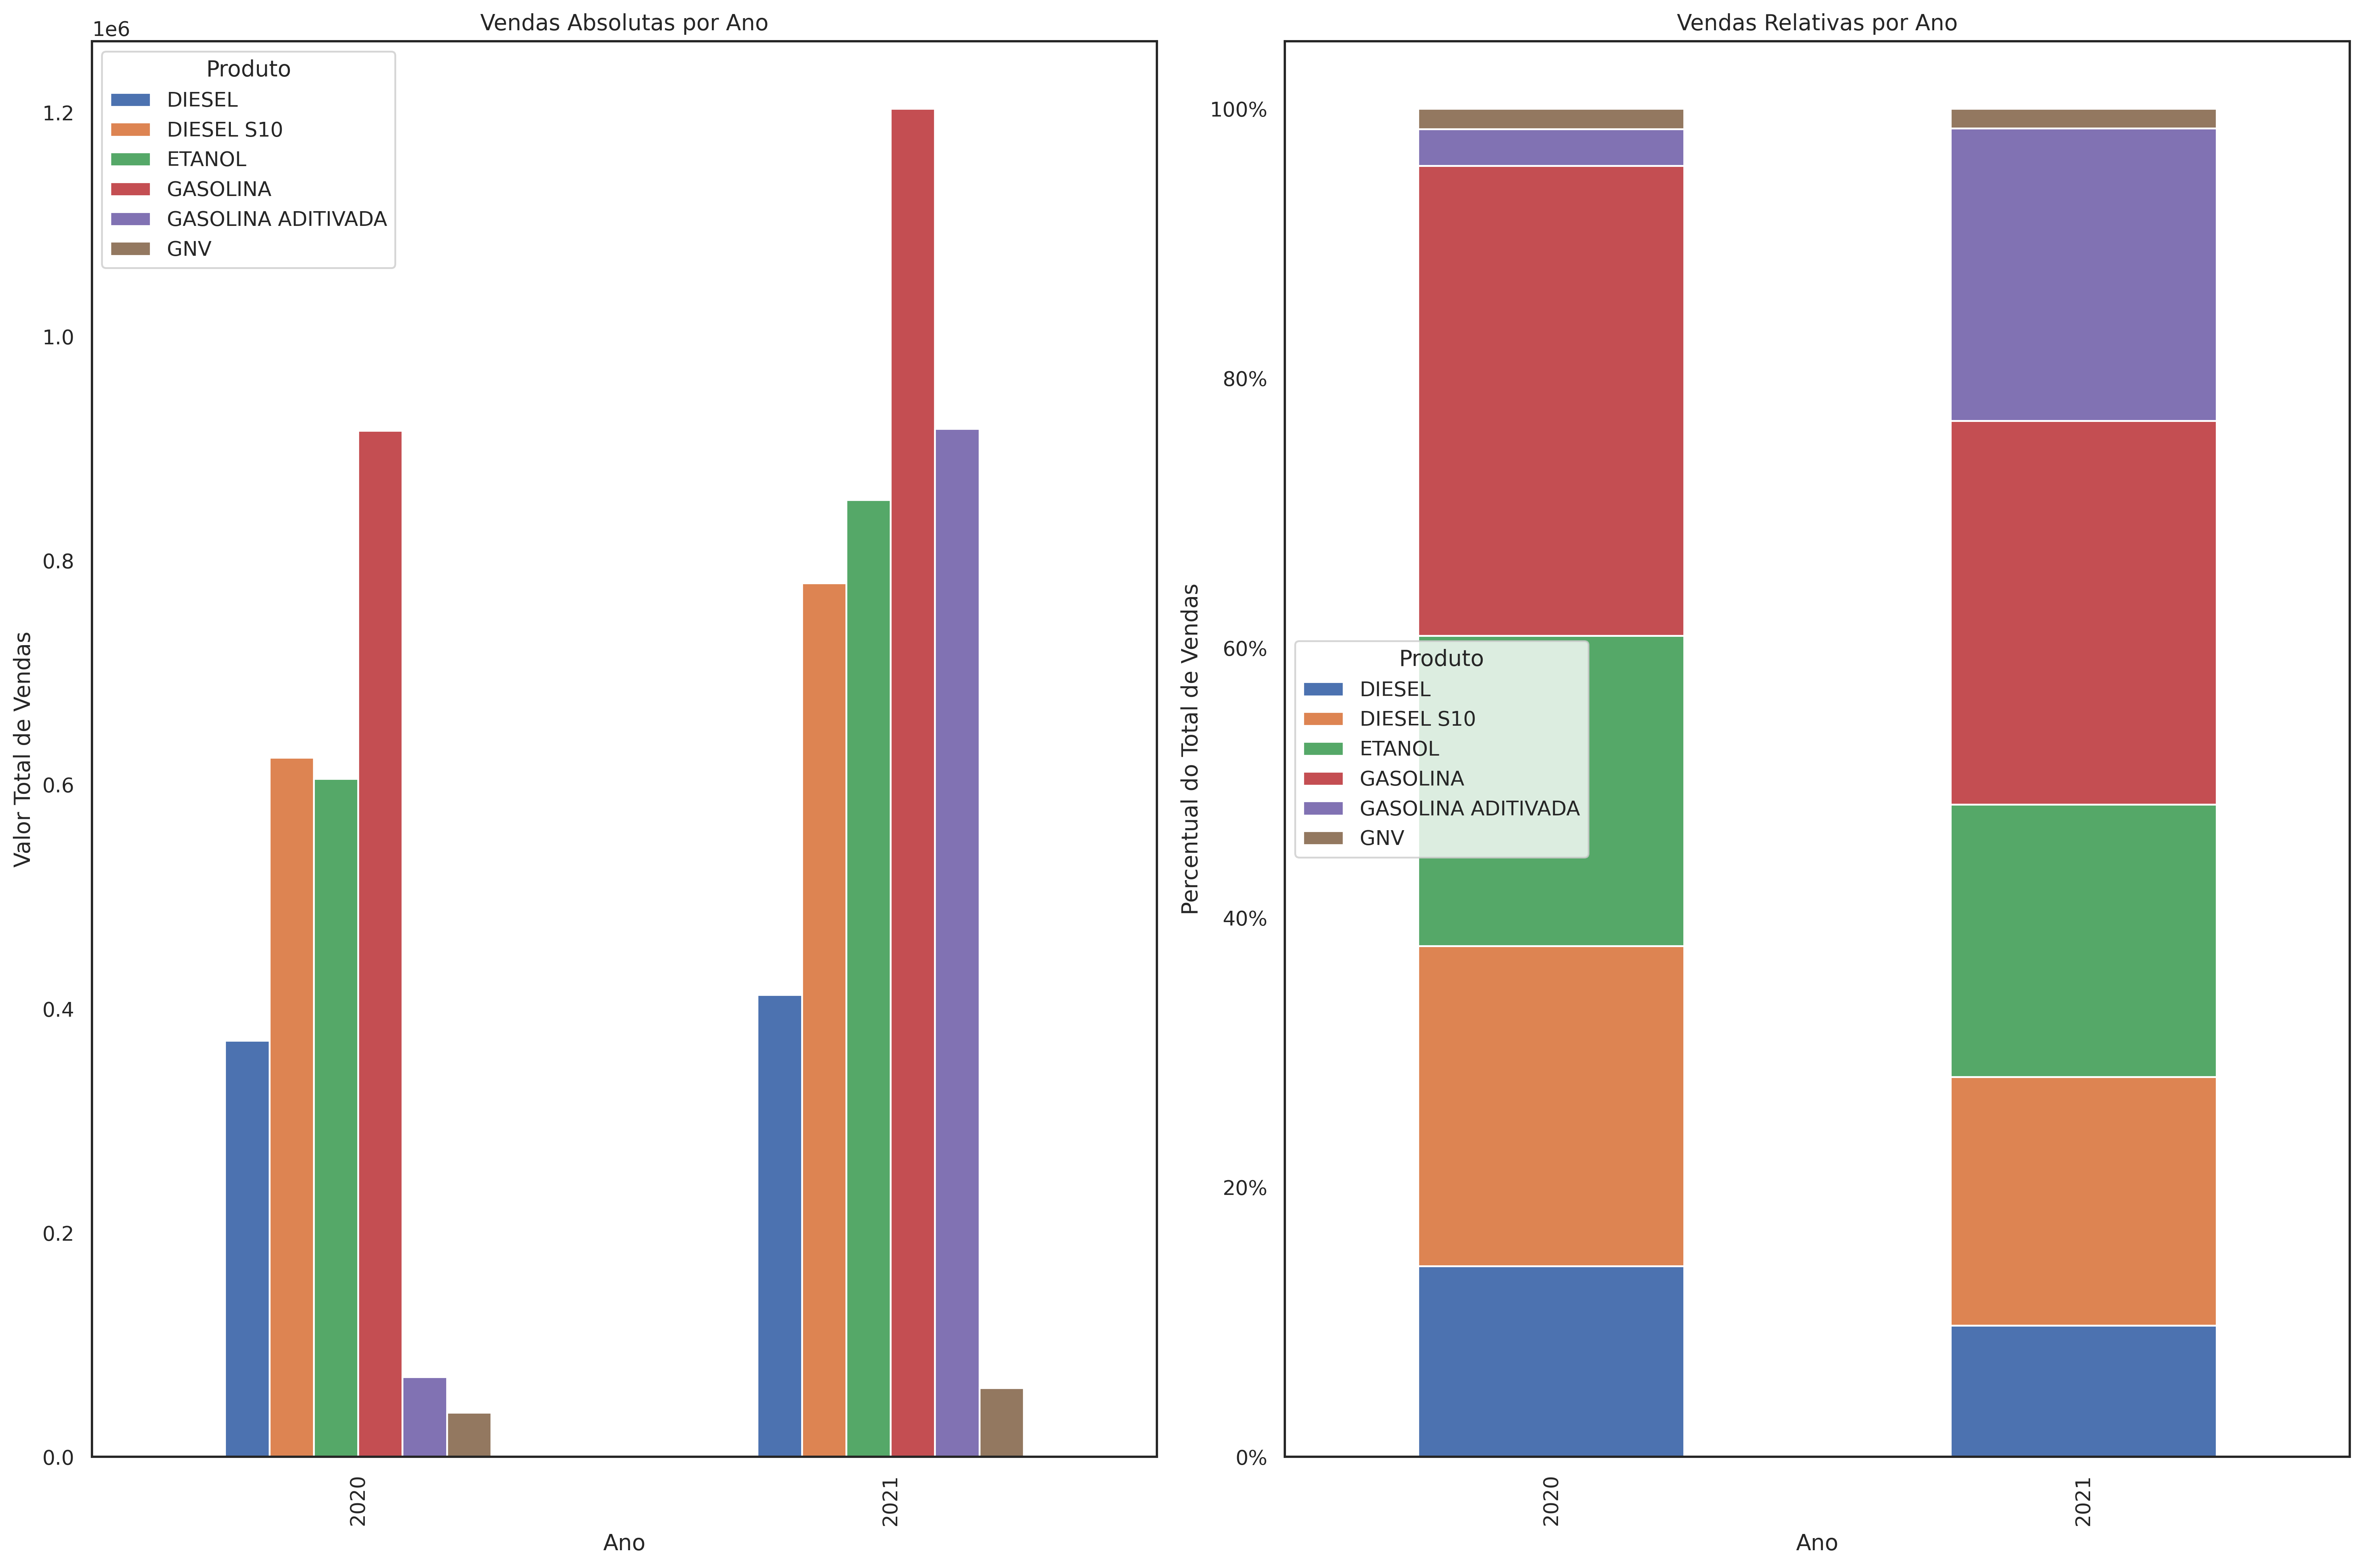

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar o dataset
df = df_precos.copy()
df['Ano'] = df['Data da Coleta'].dt.year
df = df[df['Ano'].isin([2020,2021])]

# Criando o crosstab para valores absolutos
vendas_crosstab_abs = pd.crosstab(index=df['Ano'], columns=df['Produto'],
                                  values=df['Valor de Venda'], aggfunc='sum')

# Criando o crosstab para valores relativos (porcentagens)
vendas_crosstab_rel =  pd.crosstab(index=df['Ano'], columns=df['Produto'],
                                  values=df['Valor de Venda'], aggfunc='sum',
                                   normalize = "index")


# Configuração do plot
fig, ax = plt.subplots(1, 2, figsize=(18, 12), dpi=350,)

# Gráfico de valores absolutos
vendas_crosstab_abs.plot(kind='bar', ax=ax[0])
ax[0].set_title('Vendas Absolutas por Ano')
ax[0].set_ylabel('Valor Total de Vendas')
ax[0].set_xlabel('Ano')

# Gráfico de valores relativos
vendas_crosstab_rel.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].set_title('Vendas Relativas por Ano')
ax[1].set_ylabel('Percentual do Total de Vendas')
ax[1].set_xlabel('Ano')

# Ajuste adicional para os ticks da porcentagem no eixo y do gráfico relativo
ax[1].set_yticklabels(['{:.0%}'.format(y) for y in ax[1].get_yticks()])


# Ajustar layout
plt.tight_layout()

plt.show()


#### Desafios de Customização no Gráfico Duplo

- **Uma única legenda para dois eixos**: repetir a legenda em ambos os painéis gera redundância; uma legenda compartilhada é mais limpa  
- **Rótulos nas barras do gráfico relativo**: facilita a leitura direta das proporções sem exigir que o leitor mapeie visualmente a barra ao eixo Y

/tmp/ipykernel_106719/724663752.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(['{:.0%}'.format(y) for y in ax[1].get_yticks()])


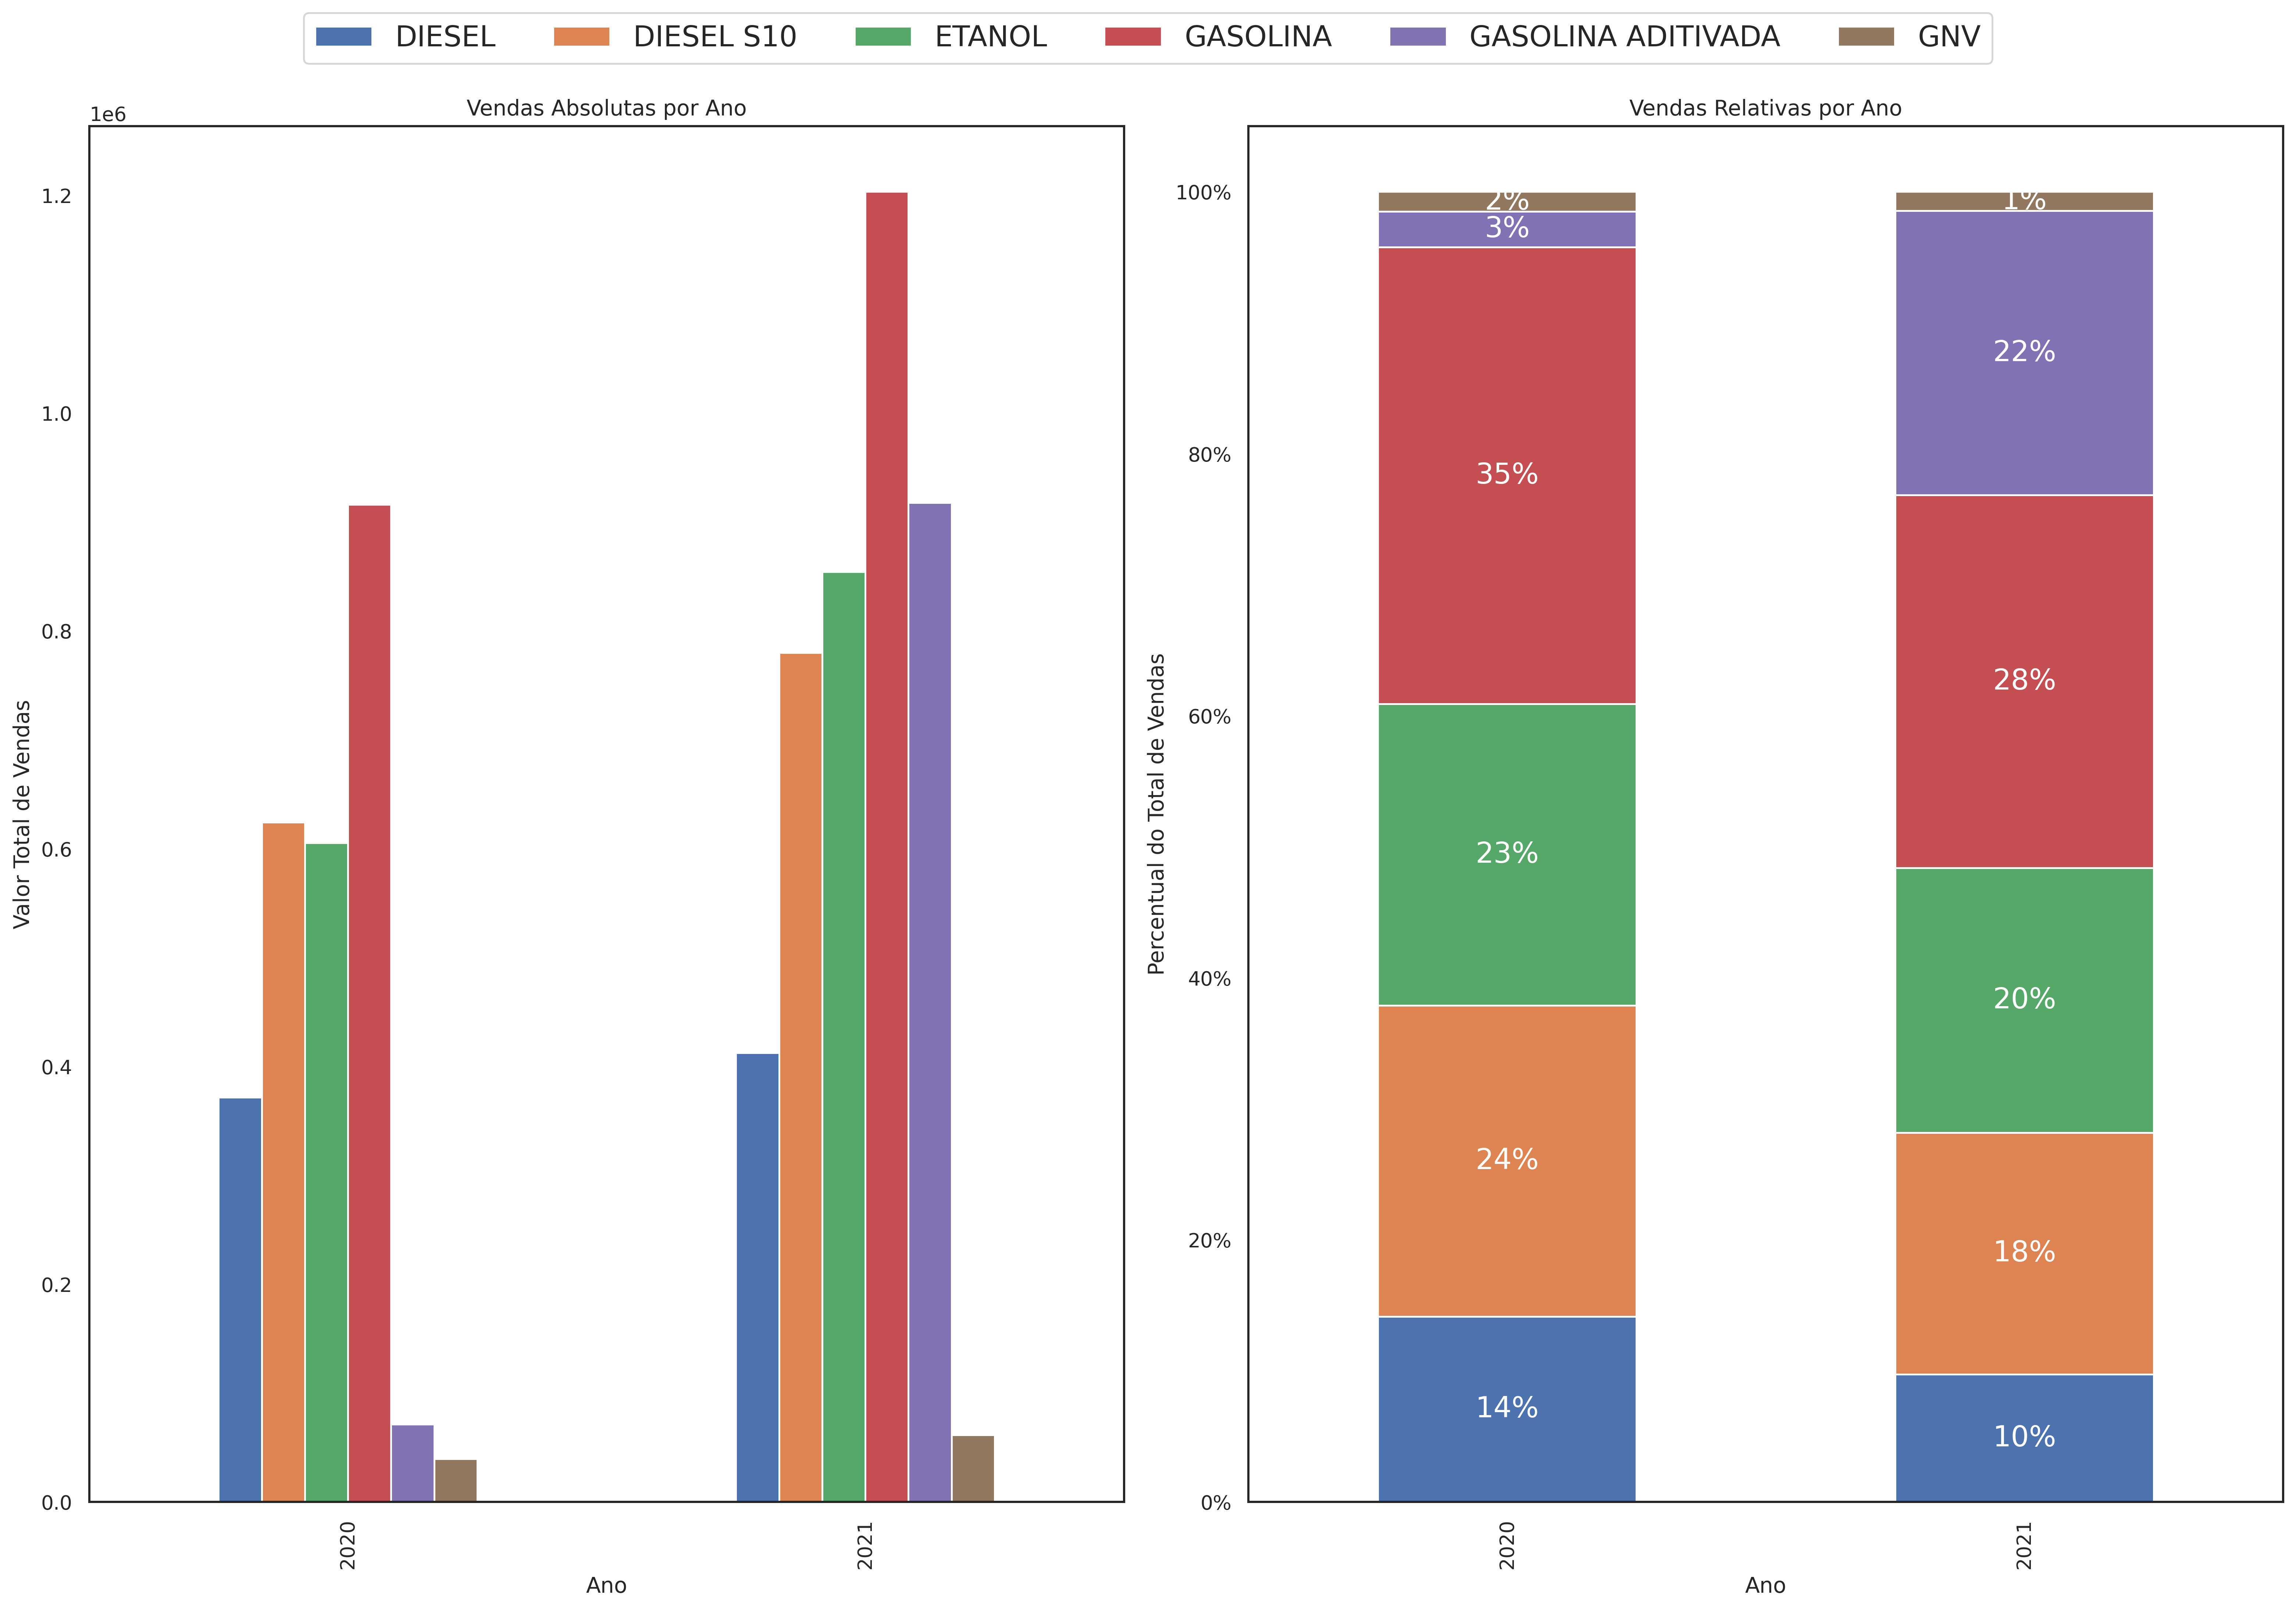

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar o dataset
df = df_precos.copy()
df['Ano'] = df['Data da Coleta'].dt.year
df = df[df['Ano'].isin([2020,2021])]

# Criando o crosstab para valores absolutos
vendas_crosstab_abs = pd.crosstab(index=df['Ano'], columns=df['Produto'],
                                  values=df['Valor de Venda'], aggfunc='sum')

# Criando o crosstab para valores relativos (porcentagens)
vendas_crosstab_rel =  pd.crosstab(index=df['Ano'], columns=df['Produto'],
                                  values=df['Valor de Venda'], aggfunc='sum',normalize = "index")


# Configuração do plot
fig, ax = plt.subplots(1, 2, figsize=(18, 12), dpi=350,)

# Gráfico de valores absolutos
vendas_crosstab_abs.plot(kind='bar', ax=ax[0])
ax[0].set_title('Vendas Absolutas por Ano')
ax[0].set_ylabel('Valor Total de Vendas')
ax[0].set_xlabel('Ano')

# Gráfico de valores relativos
vendas_crosstab_rel.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].set_title('Vendas Relativas por Ano')
ax[1].set_ylabel('Percentual do Total de Vendas')
ax[1].set_xlabel('Ano')

# Ajuste adicional para os ticks da porcentagem no eixo y do gráfico relativo
ax[1].set_yticklabels(['{:.0%}'.format(y) for y in ax[1].get_yticks()])

# Remover legendas individuais dos subplots
ax[0].get_legend().remove()
ax[1].get_legend().remove()

# Cria uma única legenda centralizada para a figura inteira
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels),
           bbox_to_anchor=(0.5, 1.05),fontsize=16)


# Adicionar labels aos valores relativos
for bars in ax[1].containers:
    # Dentro de cada grupo de barras empilhadas
    ax[1].bar_label(bars, label_type='center',  fmt=lambda x: f'{x*100:.0f}%',
                    color='white', fontsize=16)
    
# Ajustar layout
plt.tight_layout()

plt.show()


## 4. Visualizações de Tendência: Séries Temporais

Séries temporais são sequências de observações ordenadas no tempo. Na visualização de dados, o eixo temporal deve ser tratado como uma variável **contínua e ordenada**, o que favorece o uso de **linhas** em vez de barras, pois a linha comunica visualmente a continuidade e a progressão entre pontos.

**Princípios aplicados:**
- Eixo X sempre representa tempo (da esquerda para a direita)  
- Suavização opcional para reduzir ruído sem perder tendência  
- Anotação de eventos externos que causam rupturas na série

### Questão Analítica 4

**Como o preço médio anual da gasolina evoluiu em um estado específico ao longo de toda a série histórica disponível?**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar o dataset
df = df_precos.copy()
df['Ano'] = df['Data da Coleta'].dt.year


# Filtrar por tipo de produto (Gasolina) e estado específico, por exemplo, 'SP'
df_gasolina_sp = df[(df['Produto'] == 'GASOLINA') & (df['Estado - Sigla'] == 'SP')]

# Agrupar por ano e calcular o preço médio da gasolina
preco_medio_por_ano = df_gasolina_sp.groupby('Ano')['Valor de Venda'].mean().reset_index()

# Plotar o gráfico de linha
plt.figure(figsize=(10, 6))  # Define o tamanho da figura
plt.plot(preco_medio_por_ano['Ano'], preco_medio_por_ano['Valor de Venda'], marker='o', 
         linestyle='-')

# Adicionar título e rótulos
plt.title('Variação do Preço Médio da Gasolina em SP ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Preço Médio da Gasolina (R$)')

# Adicionar grades para melhor leitura
plt.grid(True)

# Mostrar o gráfico
plt.show()



### Técnicas de Aprimoramento da Série Temporal

- **Suavização por interpolação**: reduz a variação pontual sem alterar a tendência geral — útil quando os dados têm ruído de coleta  
- **Marcação de pontos críticos**: evidencia picos e vales com marcadores (`scatter`) sobre a linha  
- **Banda de confiança**: exibe o intervalo entre mínimo e máximo como área sombreada, comunicando variabilidade além da média

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import numpy as np

# Carregar o dataset
df = df_precos.copy()
df['Ano'] = df['Data da Coleta'].dt.year


# Filtrar por tipo de produto (Gasolina) e estado específico, por exemplo, 'SP'
df_gasolina_sp = df[(df['Produto'] == 'GASOLINA') & (df['Estado - Sigla'] == 'SP')]
df_gasolina_rj =  df[(df['Produto'] == 'GASOLINA') & (df['Estado - Sigla'] == 'RJ')]

# Agrupar por ano e calcular o preço médio da gasolina
preco_medio_por_ano_sp = df_gasolina_sp.groupby('Ano')['Valor de Venda'].mean().reset_index()
preco_medio_por_ano_rj = df_gasolina_rj.groupby('Ano')['Valor de Venda'].mean().reset_index()

# Converta os anos para inteiros para corrigir os labels do eixo X
preco_medio_por_ano_sp['Ano'] = preco_medio_por_ano_sp['Ano'].astype(int)
preco_medio_por_ano_rj['Ano'] = preco_medio_por_ano_rj['Ano'].astype(int)

# Crie o gráfico com os pontos mais escuros
plt.figure(figsize=(10, 6))
plt.plot(preco_medio_por_ano_sp['Ano'], preco_medio_por_ano_sp['Valor de Venda'], 
         marker='o', linestyle='-', color='skyblue',  label='SP',linewidth=2)

plt.plot(preco_medio_por_ano_rj['Ano'], preco_medio_por_ano_rj['Valor de Venda'], 
         marker='o', linestyle='-', color='mistyrose', label='RJ', linewidth=2)

# Agora, destaque os pontos plotando-os separadamente
plt.scatter(preco_medio_por_ano_sp['Ano'], preco_medio_por_ano_sp['Valor de Venda'], 
            color='blue', zorder=5)
plt.scatter(preco_medio_por_ano_rj['Ano'], preco_medio_por_ano_rj['Valor de Venda'], 
            color='red', zorder=5)

# Corrigir os labels do eixo X para mostrar anos inteiros
plt.xticks(preco_medio_por_ano_sp['Ano'].unique())  # Usa os anos únicos para os ticks

# Adicionar título e rótulos
plt.title('Variação do Preço Médio da Gasolina em SP x RJ ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Preço Médio da Gasolina (R$)')

# Adicionar grades para melhor leitura
plt.grid(True)
plt.legend()
# Mostrar o gráfico
plt.show()

### 4.1 Granularidade Temporal e Resolução da Análise

A **granularidade** define o intervalo mínimo entre observações consecutivas. A escolha impacta diretamente o que é visível no gráfico:

| Granularidade | Revela | Oculta |
|---|---|---|
| **Anual** | Tendências de longo prazo | Sazonalidade, picos mensais |
| **Trimestral** | Ciclos sazonais | Variações semanais |
| **Mensal** | Reajustes pontuais | Flutuações diárias |
| **Semanal/Diária** | Volatilidade de curto prazo | Tendência estrutural |

> Escolha a granularidade que responda à sua pergunta — não a mais detalhada disponível.

### Série Temporal com Granularidade Trimestral e Plotly Interativo

A visualização interativa (Plotly) é especialmente vantajosa em séries longas: o leitor pode **dar zoom** em períodos de interesse, **passar o cursor** para ver valores exatos, e **ocultar séries** clicando na legenda — funcionalidades inexistentes em gráficos estáticos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.dates as mdates
import plotly.express as px
import plotly.io as pio

import pandas as pd
import plotly.express as px
import plotly.io as pio
import locale

# Tentar configurar o locale para Português Brasil
locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')


# Carregar o dataset
df = df_precos.copy()
df_gasolina = df[(df['Produto'] == 'GASOLINA') & (df['Estado - Sigla'] == 'SP')]

# Converter 'Data da Coleta' para datetime e extrair o ano e trimestre
df_gasolina['Ano'] = df_gasolina['Data da Coleta'].dt.year
df_gasolina['Trimestre'] = df_gasolina['Data da Coleta'].dt.to_period('Q')

# Agrupar por ano e trimestre e calcular o preço médio
preco_medio_por_trimestre = df_gasolina.groupby(['Ano', 'Trimestre'])['Valor de Venda'].mean().reset_index()
preco_medio_por_trimestre['Trimestre'] = preco_medio_por_trimestre['Trimestre'].dt.to_timestamp()

# Criar o gráfico de linha usando Plotly Express
fig = px.line(preco_medio_por_trimestre, x='Trimestre', y='Valor de Venda',
              title='Variação Trimestral do Preço Médio da Gasolina em SP',
              labels={'Valor de Venda': 'Preço Médio da Gasolina (R$)', 'Trimestre': 'Trimestre'},
              markers=True)

# Personalizar o layout do gráfico
fig.update_layout(xaxis_title='Trimestre',
                  yaxis_title='Preço Médio da Gasolina (R$)',
                  xaxis=dict(tickmode='array', tickvals=preco_medio_por_trimestre['Trimestre'], 
                             ticktext=preco_medio_por_trimestre['Trimestre'].dt.strftime('%b-%Y')))



#Salvar em HTML
fig.write_html("GraficoLinha.html")
# Mostrar o gráfico
fig.show()

### 4.2 Personalização do Texto Interativo (Hover)

Em gráficos interativos Plotly, o *hover text* é o texto exibido ao posicionar o cursor sobre um ponto. Personalizá-lo transforma o gráfico de uma visualização exploratória para uma **ferramenta analítica completa**: o leitor obtém contexto imediato sem precisar retornar a tabelas ou relatórios.

Elementos úteis no hover:
- Data formatada no idioma do público-alvo  
- Valor com unidade explícita (R$/L)  
- Identificação da série (produto, estado, região)

In [ ]:
import pandas as pd
import plotly.express as px

# Tentar configurar o locale para Português Brasil
locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')


# Carregar o dataset
df = df_precos.copy()


# Filtro para o produto Gasolina
df_gasolina = df[df['Produto'] == 'GASOLINA'].copy()

# Converter 'Data da Coleta' para datetime e extrair o ano e trimestre
df_gasolina['Ano'] = df_gasolina['Data da Coleta'].dt.year
df_gasolina['Trimestre'] = df_gasolina['Data da Coleta'].dt.to_period('Q')


# Agrupar por região, ano e trimestre e calcular o preço médio
preco_medio_por_trimestre_regiao = df_gasolina.groupby(['Regiao - Sigla', 'Ano', 'Trimestre'])['Valor de Venda'].mean().reset_index()
preco_medio_por_trimestre_regiao['Trimestre'] = preco_medio_por_trimestre_regiao['Trimestre'].dt.to_timestamp()

# Criar o gráfico de linha usando Plotly Express
fig = px.line(preco_medio_por_trimestre_regiao, x='Trimestre', y='Valor de Venda', color='Regiao - Sigla',
              title='Variação Trimestral do Preço Médio da Gasolina por Região',markers=True,
              labels={'Valor de Venda': 'Preço Médio da Gasolina (R$)', 'Trimestre': 'Trimestre'})

# Adicionar legenda
fig.update_layout(legend_title_text='Região')

# Dados ao passar o mouse
#fig.update_traces(mode="markers+lines", hovertemplate = "<b>Trimestre:</b> %{x} <br> <b>Valor de Venda:</b> %{y}")
#fig.update_layout(hovermode="closest")    # para exibir apenas do dado que passamos o mouse
#fig.update_layout(hovermode="x")          # para exibir todos os dados do período em cada linha 
fig.update_layout(hovermode="x unified")  # para exibir o resumo de todos os dados no período

# Mostrar o gráfico
fig.show()


## 5. Visualizações de Distribuição

Compreender a **distribuição** de uma variável quantitativa é o ponto de partida de qualquer análise estatística visual. A distribuição revela:

- **Centralidade**: onde os valores se concentram (média, mediana, moda)  
- **Dispersão**: o quão espalhados estão os valores (desvio padrão, IQR)  
- **Forma**: simetria, curtose, presença de caudas e multimodalidade  
- **Outliers**: valores extremos que podem indicar erros ou eventos excepcionais

Cada tipo de gráfico a seguir captura um aspecto diferente dessa distribuição.

<img src="https://www.alura.com.br/artigos/assets/tipo-de-visualizacao-de-dados/diagrama-visualizacao-dados.jpg" alt="Diagrama de escolha do tipo de visualização" height="343">

Fonte: https://www.alura.com.br/artigos/tipo-de-visualizacao-de-dados

### 5.1 Histograma — Frequência por Intervalo de Valor

O histograma divide o intervalo de valores em **bins** (faixas) e conta quantas observações caem em cada faixa. A escolha do número de bins influencia diretamente a interpretação:

- **Poucos bins**: suaviza demais, pode ocultar multimodalidade  
- **Muitos bins**: gera ruído, dificulta identificar a forma geral  

Regra prática: use a **raiz quadrada do número de observações** como ponto de partida (`bins=int(n**0.5)`).

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar o dataset
df = df_precos.copy()
# Converter 'Data da Coleta' para datetime
df_precos['Ano'] = df_precos['Data da Coleta'].dt.year


# Filtrar dados para gasolina no ano específico, por exemplo, 2020
df_gasolina_2020 = df_precos[(df_precos['Produto'] == 'GASOLINA') & 
                             (df_precos['Ano'] == 2020) & (df['Regiao - Sigla'].isin(["SE","S"])) ]

# Definir o tamanho da figura
plt.figure(figsize=(12, 6))

# Criar um histograma com múltiplos subplots (um para cada região)
g = sns.FacetGrid(df_gasolina_2020, col="Regiao - Sigla",  height=3)
g.map(sns.histplot, "Valor de Venda", kde=False, binwidth=0.1, color='blue')

# Adicionar títulos e labels
g.fig.suptitle('Distribuição dos Preços da Gasolina por Região em 2020', y=1.03)
g.set_axis_labels('Preço da Gasolina (R$)', 'Frequência')
g.set_titles('Região: {col_name}')

# Mostrar o gráfico
plt.show()


### 5.2 Estimativa de Densidade por Kernel (KDE)

A curva KDE (*Kernel Density Estimation*) é uma versão suavizada do histograma: em vez de contar observações em faixas, ela estima a **densidade de probabilidade** de forma contínua. Vantagem: não depende da escolha do número de bins.

Interpretar a área sob a curva como probabilidade: a área entre dois valores corresponde à proporção de observações naquele intervalo.

A visualização de informações frequentemente utiliza gráficos de densidade para representar a distribuição de dados contínuos. Esses gráficos fornecem uma compreensão visual da distribuição subjacente dos dados, o que é útil para identificar padrões e tendências que podem não ser evidentes em outras formas de representação estatística.

---

## Gráficos de Densidade na Visualização de Informação

### Definição

- **Gráfico de Densidade**: Uma representação suave da distribuição de dados contínuos, semelhante a um histograma, mas com uma curva contínua que descreve a probabilidade da variável ao longo de um intervalo.

### Características

- **Suavidade**: Ao contrário dos histogramas, os gráficos de densidade usam uma curva suave que pode dar uma melhor ideia da forma da distribuição dos dados.
- **Estimativa de Kernel**: A curva é gerada usando uma estimativa de densidade de kernel, que soma as distribuições de cada ponto de dados.


### Utilidade

- **Comparação de Distribuições**: Gráficos de densidade são especialmente úteis quando você precisa comparar a distribuição de várias variáveis ou grupos em uma única visualização.
- **Visualizar a Forma da Distribuição**: Eles ajudam a visualizar a forma da distribuição dos dados, como a presença de multimodalidade, o que pode indicar a presença de diferentes subgrupos dentro dos dados.


### Como Interpretar

- **Picos**: Representam onde os dados são mais concentrados.
- **Largura da Curva**: Indica a dispersão dos dados; curvas mais largas sugerem maior variabilidade.
- **Área Sob a Curva**: Sempre integra a 1, refletindo a ideia de probabilidade total.


### Aplicação em Dados

- **Dados Contínuos**: Ótimo para dados como alturas, pesos, medidas de tempo, onde a continuidade é uma característica.
- **Análise Exploratória de Dados**: Usado frequentemente em análises exploratórias para ter uma visão rápida da forma dos dados.


### Exemplo Prático

- **Visualizando Alturas**: Ao estudar a altura de uma população, um gráfico de densidade pode mostrar rapidamente se existem alturas predominantes e quão uniformemente as alturas estão distribuídas.


### Conclusão

Gráficos de densidade são ferramentas poderosas na visualização de informações, permitindo aos analistas e ao público geral compreender rapidamente a distribuição dos dados, suas características centrais e a variabilidade inerente a eles.


--- 

A utilização correta dos gráficos de densidade pode oferecer insights valiosos que suportam tanto o conhecimento científico quanto as decisões baseadas em dados no mundo dos negócios, na pesquisa acadêmica e em muitos outros campos.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar o dataset
df = df_precos.copy()
# Converter 'Data da Coleta' para datetime
df_precos['Ano'] = df_precos['Data da Coleta'].dt.year


# Filtrar dados para gasolina no ano específico, por exemplo, 2020
df_gasolina_2020 = df_precos[(df_precos['Produto'] == 'GASOLINA') & 
                             (df_precos['Ano'] == 2020) & (df['Regiao - Sigla'].isin(["SE","S"])) ]

# Definir o tamanho da figura
plt.figure(figsize=(12, 6))

# Plotar gráfico de densidade para cada região
for regiao in df_gasolina_2020['Regiao - Sigla'].unique():
    subset = df_gasolina_2020[df_gasolina_2020['Regiao - Sigla'] == regiao]
    sns.kdeplot(data=subset['Valor de Venda'], label=regiao, fill=True)

# Adicionar título e legendas
plt.title('Distribuição dos Preços da Gasolina por Região em 2020')
plt.xlabel('Preço da Gasolina (R$)')
plt.ylabel('Densidade')
plt.legend(title='Região')

# Mostrar o gráfico
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Carregar o dataset
df = df_precos.copy()
# Extrair Ano da 'Data da Coleta'
df_precos['Ano'] = df_precos['Data da Coleta'].dt.year

# Filtrar dados para gasolina e para o ano específico, por exemplo, 2020
df_gasolina_2020_SE = df_precos[(df_precos['Produto'] == 'GASOLINA') &
                                (df_precos['Data da Coleta'].dt.year == 2020) & 
                                (df_precos['Regiao - Sigla'] == 'SE')]
df_gasolina_2020_S = df_precos[(df_precos['Produto'] == 'GASOLINA') & 
                               (df_precos['Data da Coleta'].dt.year == 2020) & 
                               (df_precos['Regiao - Sigla'] == 'S')]

# Definir o tamanho da figura
plt.figure(figsize=(12, 6))

# Calculando mediana, média e moda para cada região
mediana_SE = df_gasolina_2020_SE['Valor de Venda'].median()
media_SE = df_gasolina_2020_SE['Valor de Venda'].mean()
moda_SE = df_gasolina_2020_SE['Valor de Venda'].mode()[0]
mediana_S = df_gasolina_2020_S['Valor de Venda'].median()
media_S = df_gasolina_2020_S['Valor de Venda'].mean()
moda_S = df_gasolina_2020_S['Valor de Venda'].mode()[0]

# Plotar gráficos de densidade
sns.kdeplot(data=df_gasolina_2020_SE['Valor de Venda'], label='SE', fill=True)
sns.kdeplot(data=df_gasolina_2020_S['Valor de Venda'], label='S', fill=True)

# Adicionar linhas verticais para mediana, média e moda
#plt.axvline(mediana_SE, color='blue', linestyle='--', linewidth=2)
#plt.axvline(media_SE, color='blue', linestyle='-', linewidth=2)
#plt.axvline(moda_SE, color='blue', linestyle=':', linewidth=2)

#plt.axvline(mediana_S, color='orange', linestyle='--', linewidth=2)
#plt.axvline(media_S, color='orange', linestyle='-', linewidth=2)
#plt.axvline(moda_S, color='orange', linestyle=':', linewidth=2)

# Adicionar legendas para as linhas
#plt.text(mediana_SE, plt.gca().get_ylim()[1], 'Mediana SE', color='blue', ha='right')
#plt.text(media_SE, plt.gca().get_ylim()[1], 'Média SE', color='blue', ha='right')
#plt.text(moda_SE, plt.gca().get_ylim()[1], 'Moda SE', color='blue', ha='right')

#plt.text(mediana_S, plt.gca().get_ylim()[1], 'Mediana S', color='orange', ha='left')
#plt.text(media_S, plt.gca().get_ylim()[1], 'Média S', color='orange', ha='left')
#plt.text(moda_S, plt.gca().get_ylim()[1], 'Moda S', color='orange', ha='left')

# Adicionar título e legendas
plt.title('Distribuição dos Preços da Gasolina por Região em 2020 com Mediana, Média e Moda', y = 1.1)
plt.xlabel('Preço da Gasolina (R$)')
plt.ylabel('Densidade')
plt.legend()

ax = plt.gca()  # Obter o objeto Axes atual

# Remover a moldura (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Mostrar o gráfico
plt.show()


### 5.2.1 Distribuição Acumulada Empírica (ECDF)

O gráfico ECDF (*Empirical Cumulative Distribution Function*) responde diretamente a perguntas do tipo: *"Qual porcentagem dos postos cobra menos que R$ X?"*. A leitura é imediata: o valor no eixo Y para qualquer ponto no eixo X fornece a proporção acumulada de observações abaixo daquele valor.

Vantagem sobre o histograma: **não requer escolha de número de bins** e preserva toda a informação da amostra.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Suponha que 'df_precos' seja o seu DataFrame carregado
df_precos['Ano'] = df_precos['Data da Coleta'].dt.year
df_precos['Mes'] = df_precos['Data da Coleta'].dt.month
UF_especifico = 'SP'
Ano_especifico = 2021
Mes_especifico = 10
# Filtrar os dados para gasolina no estado de São Paulo (SP)
df_gasolina_sp = df_precos[(df_precos['Produto'] == 'GASOLINA') & 
                           (df_precos['Estado - Sigla'] == UF_especifico) & 
                           (df_precos['Ano'] == Ano_especifico) & 
                           (df_precos['Mes'] == Mes_especifico)]



# Ordenar os valores para cálculo da distribuição acumulada
sorted_prices = np.sort(df_gasolina_sp['Valor de Venda'])

# Calcular a distribuição acumulada
cumulative_distribution = np.arange(1, len(sorted_prices)+1) / len(sorted_prices)

# Plotar a distribuição acumulada
plt.figure(figsize=(10, 7))
plt.plot(sorted_prices, cumulative_distribution, marker='.', linestyle='none')
plt.xlabel('Preço da Gasolina (R$)')
plt.ylabel('Probabilidade Acumulada')
plt.title(f'Distribuição Acumulada dos Preços da Gasolina nos munícipios de {UF_especifico} em {Mes_especifico}/{Ano_especifico}')

plt.grid(True)
plt.show()


### Interpretando a Curva ECDF dos Preços da Gasolina

A curva acumulada permite inferir diretamente:

1. **Concentração de preços**: uma curva com inclinação abrupta em certa faixa indica que a maioria dos postos pratica preços próximos entre si — mercado competitivo ou tabelamento informal  
2. **Percentil mediano (P50)**: o valor de X onde Y = 0,50 é a mediana dos preços, resistente a outliers  
3. **Amplitude interquartil (IQR)**: a distância entre X em Y=0,25 e X em Y=0,75 mensura a dispersão central  
4. **Outliers superiores**: a curva "achata" na cauda direita quando há poucos postos com preços muito acima da mediana

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_precos['Ano'] = df_precos['Data da Coleta'].dt.year
df_precos['Mes'] = df_precos['Data da Coleta'].dt.month
Regiao_especifico = 'SP'
Ano_especifico = 2020
Mes_especifico = 10

# Filtrar os dados para a região Nordeste
df_ne = df_precos[(df_precos['Estado - Sigla'] == Regiao_especifico) & 
                           (df_precos['Ano'] == Ano_especifico) & 
                           (df_precos['Mes'] == Mes_especifico)]

# Calcular a distribuição acumulada para Gasolina e EtanolObservando
for produto in ['GASOLINA', 'ETANOL']:
    subset = df_ne[df_ne['Produto'] == produto]['Valor de Venda']
    sorted_prices = np.sort(subset)
    cumulative_distribution = np.arange(1, len(sorted_prices)+1) / len(sorted_prices)
    
    # Plotar cada distribuição acumulada
    plt.plot(sorted_prices, cumulative_distribution, label=produto)

# Adicionar elementos gráficos
plt.xlabel('Preço do Combustível (R$)')
plt.ylabel('Probabilidade Acumulada')
plt.title(f'Distribuição Acumulada dos Preços dos Combustíveis dos munícipios de {Regiao_especifico} em {Mes_especifico}/{Ano_especifico}')
plt.legend()
plt.grid(True)
plt.show()


### 5.3 Box Plot (Diagrama de Caixas) — Síntese Estatística Visual

O box plot resume a distribuição em **5 estatísticas-chave**: mínimo, Q1 (25%), mediana, Q3 (75%) e máximo — excluindo valores fora do intervalo de 1,5×IQR, que são marcados como outliers.

**Vantagens:**
- Compara distribuições de múltiplos grupos lado a lado com eficiência espacial  
- Revela assimetrias e presença de outliers simultaneamente  

**Limitação:** mascara multimodalidade — dois grupos com mesmos quartis podem ter formas completamente diferentes (por isso o violino é complementar).

In [ ]:
import plotly.express as px

# Carregar o dataset
df = df_precos.copy()

# Extrair Ano da 'Data da Coleta'
df_precos['Ano'] = df_precos['Data da Coleta'].dt.year

# Filtrar o DataFrame para um estado específico, por exemplo, Rio de Janeiro (RJ)
df_combustivel_RJ = df_precos[(df_precos['Estado - Sigla'] == 'RJ') & 
                              (df_precos['Ano'] == 2020) ]

# Criar o BoxPlot com Plotly
fig = px.box(df_combustivel_RJ, x='Produto', y='Valor de Venda',
             title='Variação dos Preços dos Combustíveis no Estado do RJ em 2020',
             labels={'Produto': 'Tipo de Combustível', 'Valor de Venda': 'Preço de Venda (R$)'})

#Salvar em HTML
fig.write_html("BoxPlot.html")

# Mostrar o gráfico
fig.show()

### 5.4 Violin Plot — Box Plot com Estimativa de Densidade

O *violin plot* combina o box plot (quartis, mediana) com a curva KDE espelhada nos dois lados. O resultado é uma representação que revela não só os quartis mas também a **forma completa da distribuição** — incluindo bimodalidade.

**Quando preferir ao box plot:**  
Sempre que a forma da distribuição (multimodalidade, caudas pesadas) for relevante para a análise — ex.: comparar distribuições de preços entre anos para verificar se houve convergência ou fragmentação do mercado.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df_precos.copy()

# Extrair Ano da 'Data da Coleta'
df['Ano'] = df['Data da Coleta'].dt.year

# Filtrar o DataFrame para um estado específico, por exemplo, Rio de Janeiro (RJ)
df_combustivel_RJ_2020 = df[(df['Estado - Sigla'] == 'RJ') & 
                                    (df['Ano'] == 2020)]

# Criar o Violin Plot com Seaborn
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_combustivel_RJ_2020, x='Produto', y='Valor de Venda')

# Adicionar título e rótulos aos eixos
plt.title('Variação dos Preços dos Combustíveis no Estado do RJ em 2020')
plt.xlabel('Tipo de Combustível')
plt.ylabel('Preço de Venda (R$)')

# Mostrar o gráfico
plt.show()


### 5.5 Gráfico de Dispersão (*Scatter Plot*) — Relação entre Variáveis

O gráfico de dispersão mapeia **duas variáveis quantitativas** nos eixos X e Y, com cada ponto representando uma observação. É o principal instrumento para identificar:

- **Correlação positiva/negativa/nula** entre variáveis  
- **Padrões não-lineares** (cluster, curva, etc.)  
- **Outliers bivariados** — observações atípicas na combinação de dois atributos

<img src="https://www.alura.com.br/artigos/assets/tipo-de-visualizacao-de-dados/diagrama-visualizacao-dados.jpg" alt="Diagrama de escolha do tipo de visualização" height="343">

Fonte: https://www.alura.com.br/artigos/tipo-de-visualizacao-de-dados

Na mineração de dados, gráficos de dispersão são amplamente utilizados na **análise exploratória de dados (EDA)** para investigar relações entre atributos antes de aplicar algoritmos. Um padrão linear forte sugere que uma variável pode ser usada como preditor da outra; uma nuvem sem padrão indica variáveis independentes.

#### Questão Analítica

**Como o preço da gasolina em um município específico se distribui ao longo do tempo — há tendência crescente, ciclos ou rupturas abruptas?**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = df_precos.copy()

# Extrair Ano da 'Data da Coleta'
df['Ano'] = df['Data da Coleta'].dt.year

# Filtrar os dados para um município específico e para o produto 'GASOLINA'
municipio_especifico = 'SAO PAULO'  # Substitua pelo nome real do município
df_gasolina_municipio = df[(df['Municipio'] == municipio_especifico) & 
                                  (df['Produto'] == 'GASOLINA') & (df['Ano']==2021)]

# Ordenar os dados pela 'Data da Coleta' para que o gráfico faça mais sentido

df_gasolina_municipio = df_gasolina_municipio.sort_values(by='Data da Coleta')

# Criar o gráfico de dispersão
plt.figure(figsize=(12, 6))
plt.scatter(df_gasolina_municipio['Data da Coleta'], df_gasolina_municipio['Valor de Venda'])

# Adicionar título e rótulos aos eixos
plt.title(f'Variação do Preço da Gasolina ao Longo do Tempo em {municipio_especifico}')
plt.xlabel('Data da Coleta')
plt.ylabel('Preço da Gasolina (R$)')

# Melhorar a formatação do eixo x para lidar com datas
plt.gcf().autofmt_xdate()  # Auto formatar o eixo x para datas

# Mostrar o gráfico
plt.show()


#### Questão Analítica

**Existe correlação entre o preço médio da gasolina e o preço médio do etanol nas diferentes regiões brasileiras?**

A resposta tem implicações práticas: se os preços se movem juntos, um único indicador pode representar ambos; se divergem, fatores regionais específicos (produção de cana, logística) afetam cada combustível de forma independente.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suponha que df_precos já esteja carregado no ambiente
df = df_precos.copy()

# Extrair Ano da 'Data da Coleta'
df['Ano'] = df['Data da Coleta'].dt.year

Regiao = "NE"
df = df[(df['Regiao - Sigla'] == Regiao) ]

# Filtrar os dados para gasolina e etanol
df_gasolina = df[df['Produto'] == 'GASOLINA']
df_etanol = df[df['Produto'] == 'ETANOL']

# Calcular o preço médio da gasolina e do etanol por município
media_gasolina = df_gasolina.groupby('Municipio')['Valor de Venda'].mean().reset_index(name='Preco_Medio_Gasolina')
media_etanol = df_etanol.groupby('Municipio')['Valor de Venda'].mean().reset_index(name='Preco_Medio_Etanol')

# Fazer um merge dos dois DataFrames baseado no Município
df_precos_medios = pd.merge(media_gasolina, media_etanol, on='Municipio')

# Plotar o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_precos_medios, x='Preco_Medio_Gasolina', y='Preco_Medio_Etanol')

# Adicionar título e rótulos aos eixos
plt.title(f'Correlação entre os Preços Médios da Gasolina e do Etanol na região {Regiao}')
plt.xlabel('Preço Médio da Gasolina (R$)')
plt.ylabel('Preço Médio do Etanol (R$)')

# Mostrar o gráfico
plt.show()


### Interpretando o Gráfico de Dispersão — Correlação Gasolina × Etanol

A análise do scatter plot revela:

1. **Correlação positiva**: quando o preço da gasolina sobe, o do etanol tende a acompanhar — reflexo da competição direta entre os dois combustíveis no mercado brasileiro  
2. **Dispersão residual**: os pontos não se alinham perfeitamente, indicando que fatores regionais (colheita de cana, ICMS estadual) introduzem variabilidade independente  
3. **Segmentação por região**: o uso de cores por região (hue) revela se o padrão de correlação é homogêneo ou se certas regiões exibem comportamento distinto

### 5.6 Matriz de Correlação — Panorama Multivariado

Quando o interesse é examinar as relações entre **múltiplas variáveis simultaneamente**, a matriz de correlação é mais eficiente do que pares de scatter plots individuais. Cada célula da matriz exibe o coeficiente de correlação de Pearson (r) entre dois atributos, com intensidade de cor indicando a força da relação.

**Atenção:** correlação de Pearson mede apenas relações **lineares**. Relações não-lineares podem ser invisíveis nessa representação.

In [ ]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt


# Filtrar os dados para a região Nordeste
#df_ne = df_precos[df_precos['Regiao - Sigla'] == 'NE']
df_ne = df_precos[df_precos['Produto'] != 'ETANO']

# Calcular os preços médios por município e por produto
df_precos_medios = df_ne.pivot_table(index='Municipio', columns='Produto', 
                                     values='Valor de Venda', aggfunc='mean')

# Calcular a matriz de correlação entre os tipos de combustíveis
corr_matrix = df_precos_medios.corr().round(1)

fig = px.imshow(corr_matrix, text_auto=True, color_continuous_scale='RdBu_r',aspect="auto")

fig.update_layout(
    title='Correlação entre Preços de Combustíveis no Brasil',
    xaxis_nticks=10)

fig.show()


### Interpretando a Matriz de Correlação dos Combustíveis

Da matriz, podemos extrair:

1. **Correlações positivas fortes** (r próximo a +1, cores quentes): os preços dos diferentes combustíveis tendem a subir e cair juntos, reflexo de custos compartilhados (petróleo, logística, tributação)  
2. **Grau de interdependência**: a presença de correlações altas entre gasolina, diesel e etanol indica que choques de preço em um produto rapidamente se propagam aos demais  
3. **Variáveis independentes**: colunas/linhas com valores de r próximos a 0 indicam atributos que variam por razões próprias, sem associação com os demais

---

# 6. Visualização de Texto — Dados Não Estruturados

## Introdução

Dados não estruturados — textos, imagens, áudios — correspondem a mais de 80% do volume de dados gerados globalmente. A visualização desses dados exige técnicas específicas para extrair padrões interpretáveis a partir de representações de alta dimensão.

**Nesta seção**, focamos em **dados textuais**, cobrindo:
- Representação de frequência de termos (*Word Cloud*)  
- Análise de polaridade de sentimentos com *TextBlob*

## Ferramentas para Processamento de Texto

| Biblioteca | Função |
|---|---|
| **NLTK** | Tokenização, remoção de stopwords, stemming |
| **WordCloud** | Geração de nuvens de palavras ponderadas por frequência |
| **TextBlob** | Análise de sentimentos (polaridade e subjetividade) |
| **deep-translator** | Tradução automática (necessária pois TextBlob opera em inglês) |

> **Pré-requisito:** textos em português devem ser traduzidos antes da análise de sentimentos com TextBlob, pois o modelo interno é treinado em inglês.

## 6.1 Nuvem de Palavras (*Word Cloud*)

A nuvem de palavras representa **frequência relativa de termos** por meio do tamanho tipográfico: termos mais frequentes aparecem maiores. É uma visualização exploratória que permite identificar rapidamente os tópicos dominantes em um corpus.

**Limitações:**
- Não comunica relações semânticas entre termos  
- Palavras longas ocupam mais espaço visual, podendo distorcer a percepção de frequência  
- Requer remoção prévia de *stopwords* (artigos, preposições) para evitar que termos sem valor analítico dominem a visualização

In [ ]:
import pandas as pd
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

# Carregar os dados
texto = 'A guerra na Ucrânia é uma luta pela verdade e pela soberania interpretativa.\
         Para muitos ucranianos, é uma luta pela defesa e liberdade do seu país.\
         A guerra na Ucrânia pode arrastar-se, mas não indefinidamente.\
         A Ucrânia está a perder "o ânimo" na guerra, com a população e o exército a sentirem-se desanimados.\
         A ajuda do Ocidente tarda em chegar e as munições para combater a Rússia começam a faltar.\
         A guerra na Ucrânia é fomentada pelos interesses de vários “impérios”, não apenas da Rússia.\
         A chegada do inverno complica ainda mais a situação do exército ucraniano.'

# Suponha um dataframe com uma coluna 'comentarios' contendo texto
df = pd.DataFrame({
    'comentarios': [texto]
})

# Preprocessamento dos textos
# Converter para minúsculas e remover pontuação
df['texto_limpo'] = df['comentarios'].str.lower().str.replace(r'[^\w\s]', '', regex=True)


# Tokenização dos textos
# Suponha que o texto está em português
nltk.download('punkt')
df['tokens'] = df['texto_limpo'].apply(nltk.word_tokenize)

# Remover stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese'))
df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

# Achatando a lista de tokens e contando as frequências
all_words = [word for sublist in df['tokens'] for word in sublist]
freq_dist = nltk.FreqDist(all_words)

# Criar e exibir a Word Cloud
wc = WordCloud(width=800, height=400, max_words=100).generate_from_frequencies(freq_dist)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


## 6.2 Análise de Sentimentos

A análise de sentimentos (*Sentiment Analysis*) classifica textos quanto à sua **polaridade emocional**: positiva, negativa ou neutra. É uma técnica de Processamento de Linguagem Natural (PLN) com ampla aplicação em:

- Monitoramento de redes sociais e reputação de marcas  
- Avaliação de feedback de clientes (reviews, pesquisas)  
- Análise de notícias e relatórios para apoio à decisão

**Saída do TextBlob:**
- `polarity` ∈ [-1, 1]: −1 = muito negativo, 0 = neutro, +1 = muito positivo  
- `subjectivity` ∈ [0, 1]: 0 = objetivo/factual, 1 = altamente subjetivo

In [ ]:
# tweets reais
tweets = [
    "Incrível como esse novo filme me emocionou! Recomendo muito a todos que gostam de uma boa história.",
    "Terrível experiência no restaurante ontem à noite. Demorou uma eternidade para servir e o pedido ainda veio errado!",
    "Hoje o dia está lindo, sol brilhando e não uma nuvem no céu. Perfeito para um passeio no parque.",
    "Estou tão desapontado com meu novo telefone... travou várias vezes já!",
    "A nova atualização do sistema está ótima, muito mais rápida e fluída. Parabéns à equipe de desenvolvimento!",
    "Não sei o que pensar sobre as notícias de hoje. Parece que as coisas estão cada vez mais complicadas.",
    "Melhor show da minha vida ontem à noite! A banda estava em sua melhor forma, que energia!",
    "Alguém recomenda um bom livro de mistério? Quero algo novo para ler no final de semana.",
    "Não aguento mais essa chuva, já são cinco dias seguidos!",
    "Que felicidade receber o prêmio de melhor estudante da turma! Todo o esforço valeu a pena."
]

In [ ]:
from deep_translator import GoogleTranslator
from textblob import TextBlob
import matplotlib.pyplot as plt

def analisar_sentimento(texto):
    # Traduzir do Português para o Inglês usando deep_translator
    tradutor = GoogleTranslator(source='pt', target='en')
    texto_traduzido = tradutor.translate(texto)
    
    # Análise de Sentimento
    analise = TextBlob(texto_traduzido)
    return analise




In [ ]:
text = "Eu amo programar em Python!\nEu amo Brasil!\nHorrível, nunca mais compro isso!\nEu não sei!"
blob = analisar_sentimento(text)
sentiments = [sentence.sentiment.polarity for sentence in blob.sentences]
frases = [sentence for sentence in blob.sentences]

plt.figure(figsize=(8, 4))
plt.plot(sentiments)
plt.title('Análise de Sentimentos por Frase')
plt.ylabel('Polaridade')
plt.xlabel('Frase')
plt.xticks(range(len(frases)), [str(i+1) for i in range(len(frases))], rotation=45)
plt.grid(True)
plt.show()

In [ ]:
frase = "Não me leva a mal"
analise = analisar_sentimento(frase)

print(f"Sentimento: {analise.sentiment}")

In [ ]:
avaliacoes = [
    "Eu realmente gostei deste produto!",
    "Horrível, nunca mais compro isso.",
    "Nada especial, mas funciona como esperado.",
    "Melhor compra que já fiz!",
    "Estou decepcionado com a qualidade.",
    "Eu não sei!"
]

for avaliacao in avaliacoes:
    analise = analisar_sentimento(avaliacao)
    sentimento = analise.sentiment.polarity
    print(f"Avaliação: '{avaliacao}' - Sentimento: {'Positivo' if sentimento > 0 else 'Negativo' if sentimento < 0 else 'Neutro'}")

## 6.3 Perspectivas de Ampliação

Para análises textuais mais avançadas, as seguintes técnicas complementam o conteúdo desta aula:

- **TF-IDF** (*Term Frequency–Inverse Document Frequency*): pondera termos pela frequência no documento e raridade no corpus — mais informativo que contagem bruta  
- **Embeddings de Palavras** (Word2Vec, GloVe): representações vetoriais que capturam relações semânticas — base para redução dimensional com t-SNE/UMAP (cf. Módulo 8, Seção 3)  
- **LDA** (*Latent Dirichlet Allocation*): modelagem de tópicos — identifica temas latentes num conjunto de documentos e permite visualização de clusters temáticos

## 6.4 Outros Tipos de Dados Não Estruturados

| Tipo | Técnica de Representação | Biblioteca |
|---|---|---|
| **Imagens** | Grade de thumbnails, t-SNE sobre embeddings CNN | PIL, sklearn |
| **Áudio** | Espectrograma (frequência × tempo) | librosa, matplotlib |
| **PDF/Documentos** | Extração de texto + Word Cloud ou TF-IDF | PyMuPDF, pdfminer |

A visualização de dados não estruturados frequentemente combina **extração de features** (transformar dados brutos em representação numérica) com **técnicas de redução dimensional** para tornar o espaço de alta dimensão interpretável — tema central do Módulo 8.

---

## 7. SPLOM — Matriz de Dispersão (*Scatter Plot Matrix*)

A **Matriz de Dispersão** (SPLOM — *Scatter PLot Matrix*) exibe todos os pares de variáveis numéricas em uma grade $d \times d$. Cada célula fora da diagonal é um scatter plot entre duas variáveis; a diagonal tipicamente exibe a distribuição univariada (histograma ou KDE).

**Quando usar:**
- EDA inicial em datasets com 3–8 variáveis numéricas
- Identificar pares com alta correlação *antes* de aplicar algoritmos de ML
- Detectar clusters visualmente ao colorir por categoria

**Questão analítica:** Como os preços médios dos diferentes combustíveis se relacionam entre si, quando comparados por estado?

> **Grammar of Graphics:** o SPLOM é um *facet* de scatter plots — o mesmo `geom_point` aplicado a todos os pares de `aes()` possíveis.

In [ ]:
import pandas as pd
import plotly.express as px

# Preparar pivot: linha = Estado, colunas = Produto, valor = Preço médio de Venda (2018-2021)
df = df_precos.copy()
df['Ano'] = df['Data da Coleta'].dt.year
df = df[df['Ano'].between(2018, 2021)]

pivot = (df.groupby(['Estado - Sigla', 'Regiao - Sigla', 'Produto'])['Valor de Venda']
           .mean()
           .reset_index()
           .pivot_table(index=['Estado - Sigla', 'Regiao - Sigla'],
                        columns='Produto',
                        values='Valor de Venda')
           .dropna(axis=1, thresh=20)   # manter combustíveis com dados suficientes
           .reset_index())

pivot.columns.name = None
pivot = pivot.rename(columns={'Estado - Sigla': 'Estado', 'Regiao - Sigla': 'Regiao'})

combustiveis = [c for c in pivot.columns if c not in ['Estado', 'Regiao']]

fig = px.scatter_matrix(
    pivot,
    dimensions=combustiveis,
    color='Regiao',
    hover_name='Estado',
    title='SPLOM — Preço Médio por Combustível e Estado (2018–2021)',
    labels={c: c.title() for c in combustiveis},
    opacity=0.75,
    height=700
)
fig.update_traces(diagonal_visible=False, marker=dict(size=6))
fig.update_layout(font=dict(size=11))
fig.show()

### Interpretando o SPLOM dos Combustíveis

- **Diagonal principal (desabilitada acima, mas pode ser ativada):** mostra a distribuição marginal de cada combustível — identifique assimetrias e estados-outlier.
- **Células fora da diagonal:** a forma da nuvem revela a relação entre pares. Nuvem em diagonal = correlação positiva forte (ex.: gasolina comum × gasolina aditivada).
- **Cor por Região:** permite verificar se o padrão de preços é homogêneo entre regiões ou se há segmentação geográfica clara.
- **Hover com nome do Estado:** identifica estados específicos com comportamento anômalo sem sobrecarregar o gráfico com rótulos.

> **Limitação:** com muitas variáveis (> 8), o SPLOM fica ilegível. Nesses casos, prefira a **Matriz de Correlação** (seção 5.6) ou reduza para os pares mais relevantes.

---

## 8. Visualização de Alta Dimensão

Datasets com muitas variáveis (> 3) não podem ser visualizados diretamente. Técnicas de **redução de dimensionalidade** projetam os dados em 2D ou 3D preservando, ao máximo, a estrutura original — seja a variância global (PCA) ou a vizinhança local (t-SNE, UMAP).

| Técnica | Tipo | Preserva | Limitação |
|---|---|---|---|
| **PCA** | Linear | Variância global | Não captura relações não-lineares |
| **t-SNE** | Não-linear | Estrutura local (vizinhos) | Lento; não transforma novos pontos |
| **UMAP** | Não-linear | Local + global | Estocástico (fixar `random_state`) |

**Estratégia deste notebook:** construir uma matriz *estado × combustível* (preço médio 2004–2021) e projetar os 27 estados em 2D pelas três técnicas, colorindo por região geográfica.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Reutilizar pivot construído na seção SPLOM (todos os anos disponíveis)
df = df_precos.copy()
df['Ano'] = df['Data da Coleta'].dt.year

pivot_full = (df.groupby(['Estado - Sigla', 'Regiao - Sigla', 'Produto'])['Valor de Venda']
               .mean()
               .reset_index()
               .pivot_table(index=['Estado - Sigla', 'Regiao - Sigla'],
                            columns='Produto',
                            values='Valor de Venda')
               .dropna(axis=1, thresh=20)
               .dropna(axis=0)
               .reset_index())

pivot_full.columns.name = None
pivot_full = pivot_full.rename(columns={'Estado - Sigla': 'Estado', 'Regiao - Sigla': 'Regiao'})

combustiveis = [c for c in pivot_full.columns if c not in ['Estado', 'Regiao']]
X = pivot_full[combustiveis].values
rotulos_estado = pivot_full['Estado'].values
rotulos_regiao = pivot_full['Regiao'].values

# Padronização: média 0, desvio padrão 1 (obrigatório antes de PCA/t-SNE/UMAP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matriz de features: {X_scaled.shape}  →  {X_scaled.shape[0]} estados × {X_scaled.shape[1]} combustíveis")
print(f"Combustíveis: {combustiveis}")

### 8.1 PCA — Análise de Componentes Principais

A PCA encontra os eixos de **máxima variância** nos dados originais e projeta cada observação nesses eixos (componentes principais):

$$\mathbf{Z} = \mathbf{X}_{scaled} \cdot \mathbf{W}, \quad \text{onde } \mathbf{W} = \text{autovetores de } \mathbf{X}^T\mathbf{X}$$

O **PCA biplot** exibe simultaneamente:
- **Pontos** = estados projetados no espaço PC1 × PC2  
- **Vetores (loadings)** = direção e magnitude da contribuição de cada combustível para cada componente  

Vetores apontando na mesma direção indicam combustíveis altamente correlacionados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_ * 100

# Mapa de cores por região
regioes = sorted(set(rotulos_regiao))
cores_regiao = {'N': '#e41a1c', 'NE': '#ff7f00', 'CO': '#4daf4a',
                'SE': '#377eb8', 'S': '#984ea3'}

fig, ax = plt.subplots(figsize=(9, 6))
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

for regiao in regioes:
    mask = rotulos_regiao == regiao
    ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1],
               color=cores_regiao[regiao], label=regiao,
               s=100, edgecolors='white', linewidths=0.5, zorder=3)
    for est, x, y in zip(rotulos_estado[mask], Z_pca[mask, 0], Z_pca[mask, 1]):
        ax.annotate(est, (x, y), textcoords='offset points', xytext=(5, 3),
                    fontsize=7, color=cores_regiao[regiao])

# Loadings (vetores dos combustíveis)
loadings = pca.components_.T  # shape: (n_features, 2)
escala = 2.5
for i, comb in enumerate(combustiveis):
    ax.annotate('', xy=(loadings[i, 0]*escala, loadings[i, 1]*escala),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.4))
    ax.text(loadings[i, 0]*escala*1.12, loadings[i, 1]*escala*1.12,
            comb.replace('GASOLINA', 'GAS').replace('DIESEL', 'DIE'),
            fontsize=7.5, ha='center', color='#333333')

ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variância explicada)', fontsize=10)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variância explicada)', fontsize=10)
ax.set_title('PCA Biplot — Estados Brasileiros × Preço de Combustíveis', fontsize=12, fontweight='bold')
ax.legend(title='Região', frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Variância total explicada pelos 2 PCs: {sum(var_exp):.1f}%")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42).fit(X_scaled)
var_acum = np.cumsum(pca_full.explained_variance_ratio_ * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Scree plot
ax1.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
        pca_full.explained_variance_ratio_ * 100,
        color='steelblue', edgecolor='white')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variância Explicada (%)')
ax1.set_title('Scree Plot')
ax1.spines[['top', 'right']].set_visible(False)

# Variância acumulada
ax2.plot(range(1, len(var_acum)+1), var_acum, 'o-', color='steelblue')
ax2.axhline(80, color='orange', linestyle='--', label='80%')
ax2.axhline(95, color='red', linestyle='--', label='95%')
ax2.set_xlabel('Número de Componentes (k)')
ax2.set_ylabel('Variância Acumulada (%)')
ax2.set_title('Variância Acumulada vs k')
ax2.legend(frameon=False)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Análise de Componentes Principais — Scree Plot', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 t-SNE — Visualização de Estrutura Local

O t-SNE (*t-distributed Stochastic Neighbor Embedding*, van der Maaten & Hinton, 2008) é um algoritmo **não-linear** que preserva a vizinhança local: pontos próximos no espaço original permanecem próximos na projeção 2D.

**Parâmetro crítico — `perplexity`:** controla o número efetivo de vizinhos considerados (tipicamente 5–50). Valores baixos enfatizam estrutura local; valores altos revelam estrutura mais global.

> **Atenção:** t-SNE é **estocástico** — resultados variam entre execuções. Use `random_state` para reprodutibilidade. Distâncias *entre* clusters no t-SNE **não têm significado** — apenas a coesão interna importa.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, perp in zip(axes, [5, 15, 30]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
    Z_tsne = tsne.fit_transform(X_scaled)

    for regiao in regioes:
        mask = rotulos_regiao == regiao
        ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                   color=cores_regiao[regiao], label=regiao,
                   s=90, edgecolors='white', linewidths=0.5, zorder=3)
        for est, x, y in zip(rotulos_estado[mask], Z_tsne[mask, 0], Z_tsne[mask, 1]):
            ax.annotate(est, (x, y), textcoords='offset points', xytext=(4, 2),
                        fontsize=6.5, color=cores_regiao[regiao])

    ax.set_title(f't-SNE  |  perplexity={perp}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(title='Região', frameon=False, fontsize=8)
plt.suptitle('t-SNE — Impacto da Perplexidade na Projeção', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 8.3 UMAP — Preservação de Estrutura Local e Global

O UMAP (*Uniform Manifold Approximation and Projection*, McInnes et al., 2018) baseia-se em geometria Riemanniana e teoria de topologia fuzzy. Em comparação ao t-SNE:

- **Mais rápido** (escala melhor para $n > 10.000$)  
- **Preserva estrutura global** além da local  
- **Permite transformar novos pontos** (`.fit()` + `.transform()`) — útil em produção  

**Parâmetros principais:**
- `n_neighbors`: quantidade de vizinhos locais considerados (5–50) — similar à perplexidade do t-SNE  
- `min_dist`: quão compactados os pontos ficam no espaço projetado (0.0–1.0)

In [ ]:
import matplotlib.pyplot as plt

try:
    import umap
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    configs = [
        dict(n_neighbors=5,  min_dist=0.1, title='n_neighbors=5  |  min_dist=0.1'),
        dict(n_neighbors=15, min_dist=0.3, title='n_neighbors=15 |  min_dist=0.3'),
    ]

    for ax, cfg in zip(axes, configs):
        reducer = umap.UMAP(n_components=2, random_state=42,
                            n_neighbors=cfg['n_neighbors'],
                            min_dist=cfg['min_dist'])
        Z_umap = reducer.fit_transform(X_scaled)

        for regiao in regioes:
            mask = rotulos_regiao == regiao
            ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1],
                       color=cores_regiao[regiao], label=regiao,
                       s=90, edgecolors='white', linewidths=0.5, zorder=3)
            for est, x, y in zip(rotulos_estado[mask], Z_umap[mask, 0], Z_umap[mask, 1]):
                ax.annotate(est, (x, y), textcoords='offset points', xytext=(4, 2),
                            fontsize=6.5, color=cores_regiao[regiao])

        ax.set_title(cfg['title'], fontsize=10, fontweight='bold')
        ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
        ax.spines[['top', 'right']].set_visible(False)

    axes[0].legend(title='Região', frameon=False, fontsize=8)
    plt.suptitle('UMAP — Projeção dos Estados por Perfil de Preços', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("UMAP não instalado. Execute: pip install umap-learn")
    print("Instalando...")
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
    print("Instalado. Reinicie o kernel e execute novamente.")

### 8.4 Comparação: PCA × t-SNE × UMAP

| Critério | PCA | t-SNE | UMAP |
|---|---|---|---|
| **Tipo** | Linear | Não-linear | Não-linear |
| **Velocidade** | Muito rápido | Lento O(n²) | Rápido O(n log n) |
| **Estrutura global** | Boa | Ruim | Boa |
| **Estrutura local** | Moderada | Excelente | Excelente |
| **Determinismo** | Sim | Não (fixar `random_state`) | Não (fixar `random_state`) |
| **Parâmetros** | Nenhum | `perplexity` | `n_neighbors`, `min_dist` |
| **Transforma novos pontos** | ✅ | ❌ | ✅ |
| **Interpretabilidade dos eixos** | ✅ (variância) | ❌ | ❌ |

**Regra prática para escolha:**
- Use **PCA** quando precisar de interpretabilidade (loadings) ou como pré-processamento antes do t-SNE/UMAP  
- Use **t-SNE** quando o foco for identificar clusters locais com alta resolução  
- Use **UMAP** quando o dataset for grande ou quando precisar aplicar a transformação em novos dados (produção)

> No exemplo acima, com apenas 27 estados, as três técnicas produzem resultados similares. A diferença se torna evidente em datasets com milhares de pontos e estrutura não-linear complexa.

## Referências

[1] Tufte, E.R. (1983). *The Visual Display of Quantitative Information*. Graphics Press.

[2] Wilkinson, L. (2005). *The Grammar of Graphics* (2nd ed.). Springer.

[3] Bertin, J. (1983). *Semiology of Graphics*. University of Wisconsin Press.

[4] van der Maaten, L. & Hinton, G. (2008). Visualizing Data using t-SNE. *Journal of Machine Learning Research*, 9, 2579–2605.

[5] Hunter, J.D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.

[6] Waskom, M. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.

[7] Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP). *Série Histórica de Preços de Combustíveis*. Disponível em: https://www.gov.br/anp/pt-br